# FluxTransformer Reservoir Experiments on E. coli iML1515

This notebook evaluates a pretrained FluxTransformer model on E. coli iML1515 metabolism and adapts it for experimental omics-to-flux benchmarking.

The first sections load the pretrained model and inspect its behavior with loss curves, diagnostic flux plots, flux-distribution checks, and flux-level metrics. The later sections train a front MLP on experimental transcriptomics, proteomics, and measured glucose/oxygen uptake values, then use the frozen FluxTransformer as a reservoir for MINN-style flux prediction.

The notebook also reproduces comparison formats from the Tazza et al. MINN paper: a pFBA comparison analogous to their Table 4, using measured glucose/oxygen constraints and FluxTransformer + pFBA constraints for CO2/ethanol/acetate, plus a TabPFN ML-to-flux benchmark reported with the same metric layout as their Table 2.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HFTOKEN")

In [2]:
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from train_flux_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [3]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [4]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [5]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        input_token_indices,          # list[int] or 1D tensor[int64]
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
    ):
        super().__init__()
        if vocab_size is None:
            raise ValueError("vocab_size must be provided explicitly.")
        self.vocab_size = int(vocab_size)
        self.d_model = d_model

        idx = torch.as_tensor(input_token_indices, dtype=torch.long)
        if idx.ndim != 1:
            raise ValueError("input_token_indices must be 1D.")
        if (idx < 0).any() or (idx >= self.vocab_size).any():
            raise ValueError("input_token_indices contains out-of-range indices.")
        # Register as buffer so it moves with .to(device)
        self.register_buffer("input_token_indices", idx, persistent=True)

        self.input_embedding = nn.Embedding(self.vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        c: (batch, vocab_size, 1)
        output_subset: 1D tensor of token indices to train on (typically excludes injected tokens)
        """
        batch_size = c.size(0)

        always = self.input_token_indices  # (n_injected,)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            output_subset = output_subset.to(c.device).long()
            selected_indices = torch.unique(torch.cat([always, output_subset]), sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)      # (B, S)
        x = self.input_embedding(y)                                    # (B, S, d_model)

        c_subset = c[:, selected_indices, :]                           # (B, S, 1)
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size(1), len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices

        return c_subset_all_layers, selected_indices

In [6]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        input_token_indices=config['input_token_indices'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [7]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    import os
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [8]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    import os
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    if display_label.endswith('_flux'):
        display_label = display_label[:-5]
    if display_label.upper().startswith('BIOMASS'):
        display_label = 'Biomass iML1515'

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    if str(label).upper().startswith('BIOMASS'):
        axs[0, 1].set_ylim(-0.05, 0.05)
    else:
        res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
        if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
            res_abs_max = 1.0
        axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [9]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs,
    flux_name: str,
    save_path=None,
    batch_size: int = 16,
    device: str | torch.device | None = None,
):
    """
    Plot diagnostics for a token name in `outputs`.

    Assumptions:
      - outputs defines token order, len(outputs) == model.vocab_size
      - X_test is (N, vocab_size) and contains medium constraints only at injected token indices
      - y_test is (N, vocab_size) and contains realized fluxes for all tokens
      - model forward returns (preds_all_layers, selected_indices)
        where preds_all_layers is (B, S, n_layers) and selected_indices are token indices
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    model = model.to(device).eval()

    # Basic sanity checks
    if len(outputs) != getattr(model, "vocab_size", None):
        raise ValueError(f"len(outputs)={len(outputs)} does not match model.vocab_size={model.vocab_size}")

    if X_test.ndim != 2 or y_test.ndim != 2:
        raise ValueError(f"Expected X_test and y_test as 2D tensors (N, vocab_size). Got {X_test.shape=}, {y_test.shape=}")

    if X_test.shape[1] != model.vocab_size or y_test.shape[1] != model.vocab_size:
        raise ValueError(
            f"Feature dim mismatch. Expected vocab_size={model.vocab_size}. "
            f"Got X_test.shape[1]={X_test.shape[1]}, y_test.shape[1]={y_test.shape[1]}"
        )

    if flux_name not in outputs:
        raise ValueError(f"Flux '{flux_name}' not in outputs (len={len(outputs)}).")

    token_idx = outputs.index(flux_name)

    pred_vals = []
    true_vals = []
    pos = None
    use_amp = device.type == "cuda"

    # Diagnostics use full-context forward (output_subset=None), which can be memory-heavy on CUDA.
    # Use a conservative default batch size on GPU unless user explicitly asks for <=2.
    if device.type == "cuda" and batch_size > 2:
        batch_size = 2

    with torch.inference_mode():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i + batch_size].to(device)          # [B, vocab_size]
            yb_true = y_test[i:i + batch_size]                # [B, vocab_size]
            c = xb.unsqueeze(-1)                              # [B, vocab_size, 1]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model(c, output_subset=None)
            else:
                preds_all_layers, selected_indices = model(c, output_subset=None)

            # Map token_idx -> its position inside selected_indices (once is enough)
            if pos is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                hit = np.where(selected_indices_np == token_idx)[0]
                if hit.size == 0:
                    raise RuntimeError(
                        f"Token index {token_idx} for '{flux_name}' was not produced by the model forward pass. "
                        "This should not happen when output_subset=None."
                    )
                pos = int(hit[0])

            yb_pred_flux = preds_all_layers[:, pos, -1].detach().cpu().numpy()
            yb_true_flux = yb_true[:, token_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.type == "cuda":
                torch.cuda.empty_cache()

    y_pred = np.concatenate(pred_vals, axis=0)
    y_true = np.concatenate(true_vals, axis=0)

    # Is this an injected (medium constraint) token slot?
    injected = False
    if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
        injected = bool((model.input_token_indices.detach().cpu() == token_idx).any().item())

    print(f"{flux_name} token index: {token_idx}")
    print(f"injected medium slot: {injected}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    # Per-flux metrics for the currently plotted token
    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = float("nan")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"R2: {r2:.4f}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )

### Load model

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
model_name = "iML1515_MINN_res_500k_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/iML1515_MINN_res_500k_d256_h8_l3_ff1024/iML1515_MINN_res_500k_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,069,729

Data information:
Dataset: ./data/iML1515_MINN_res_training_data_500k_samples.csv
Training samples: 400000
Test samples: 100000


### Load data

In [12]:
# Load data using the same function as during training
#set_seed()

#DATA_PATH = f"./data/iML1515_MINN_test_data_49982_samples.csv"
DATA_PATH = f"./data/iML1515_MINN_res_test_data_50000_samples.csv"

#X, y, inputs, outputs, input_token_indices, out_indices = load_data(data_info['dataset'])
X, y, inputs, outputs, input_token_indices, out_indices = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

model.eval()


Loaded data with 50000 samples from ./data/iML1515_MINN_res_test_data_50000_samples.csv
Extracted input columns count:  27
Extracted output columns count: 2712
Medium constraints are injected into these token indices (in outputs order):
[180, 1525, 106, 40, 45, 92, 104, 164, 304, 621, 700, 859, 913, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 1981, 86, 934, 2243, 2320, 633]
Training samples: 40000
Test samples: 10000


FluxTransformer(
  (input_embedding): Embedding(2712, 256)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((257,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=257, out_features=1024, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=1024, out_features=257, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

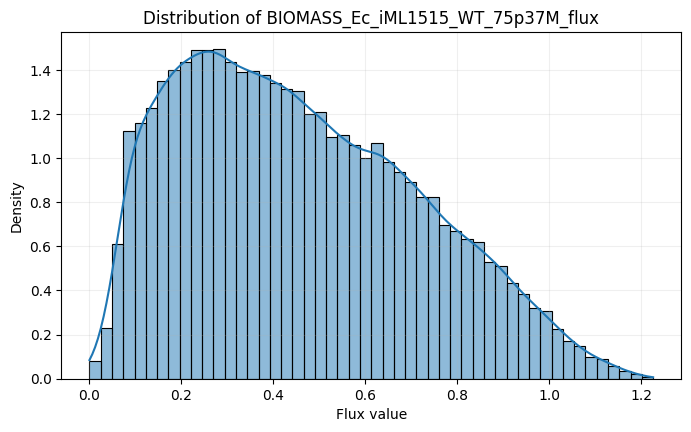

In [13]:
def plot_flux_distribution(y, outputs, flux_name, bins=50, figsize=(8, 4.5)):
    """Plot the distribution of a selected output flux from target tensor y."""
    if flux_name not in outputs:
        raise ValueError(f"{flux_name} not found in outputs.")
    flux_idx = outputs.index(flux_name)
    flux_values = y[:, flux_idx]
    if isinstance(flux_values, torch.Tensor):
        flux_values = flux_values.detach().cpu().numpy()
    else:
        flux_values = np.asarray(flux_values)

    plt.figure(figsize=figsize)
    sns.histplot(flux_values, bins=bins, kde=True, stat="density", color="tab:blue")
    plt.title(f"Distribution of {flux_name}")
    plt.xlabel("Flux value")
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.show()

plot_flux_distribution(y, outputs, "BIOMASS_Ec_iML1515_WT_75p37M_flux")

### Plot Results

In [14]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

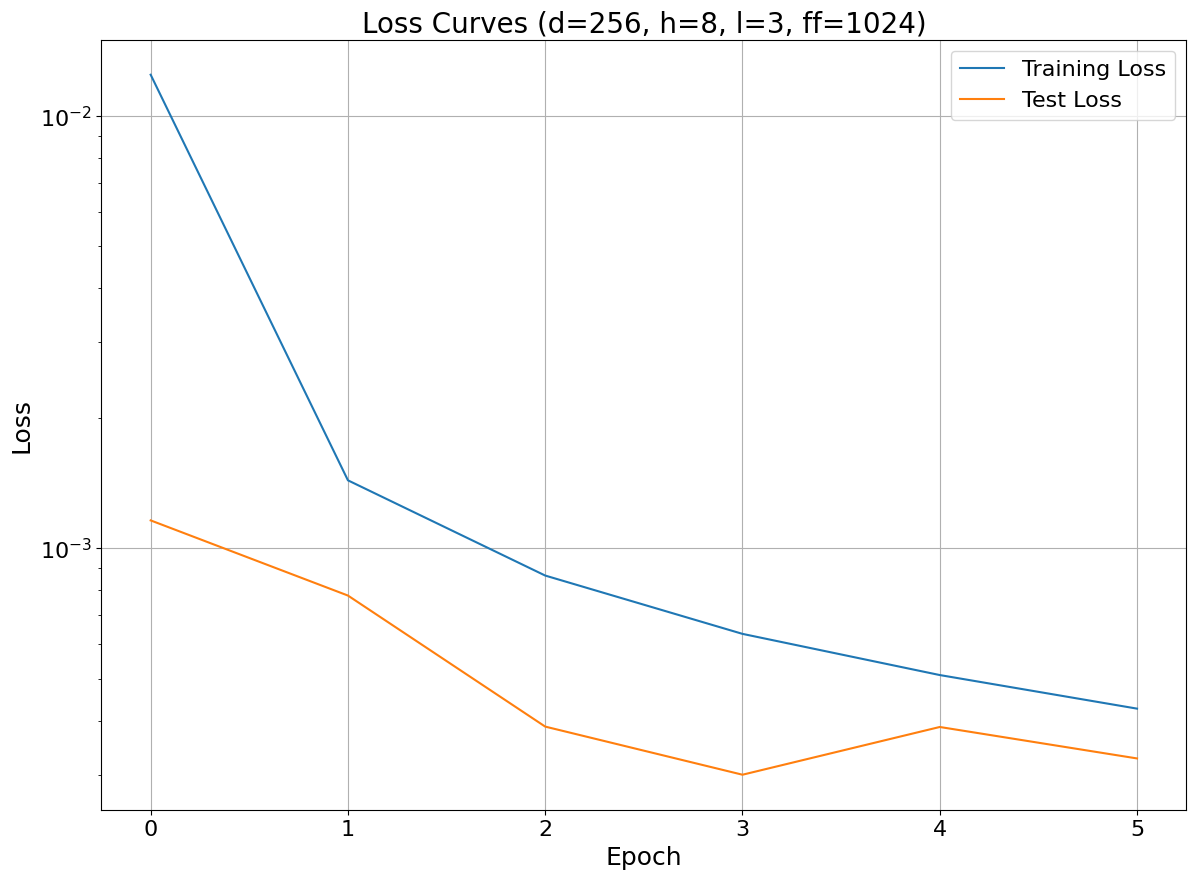

In [15]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

BIOMASS_Ec_iML1515_WT_75p37M_flux:
------------------------------------------------------------
BIOMASS_Ec_iML1515_WT_75p37M_flux token index: 2669
injected medium slot: False
y_true range: 0.0003747593145817518 to 1.2226386070251465
y_pred range: 0.01294785737991333 to 1.2110652923583984
R2: 0.9988
MAE: 0.007555
RMSE: 0.009081


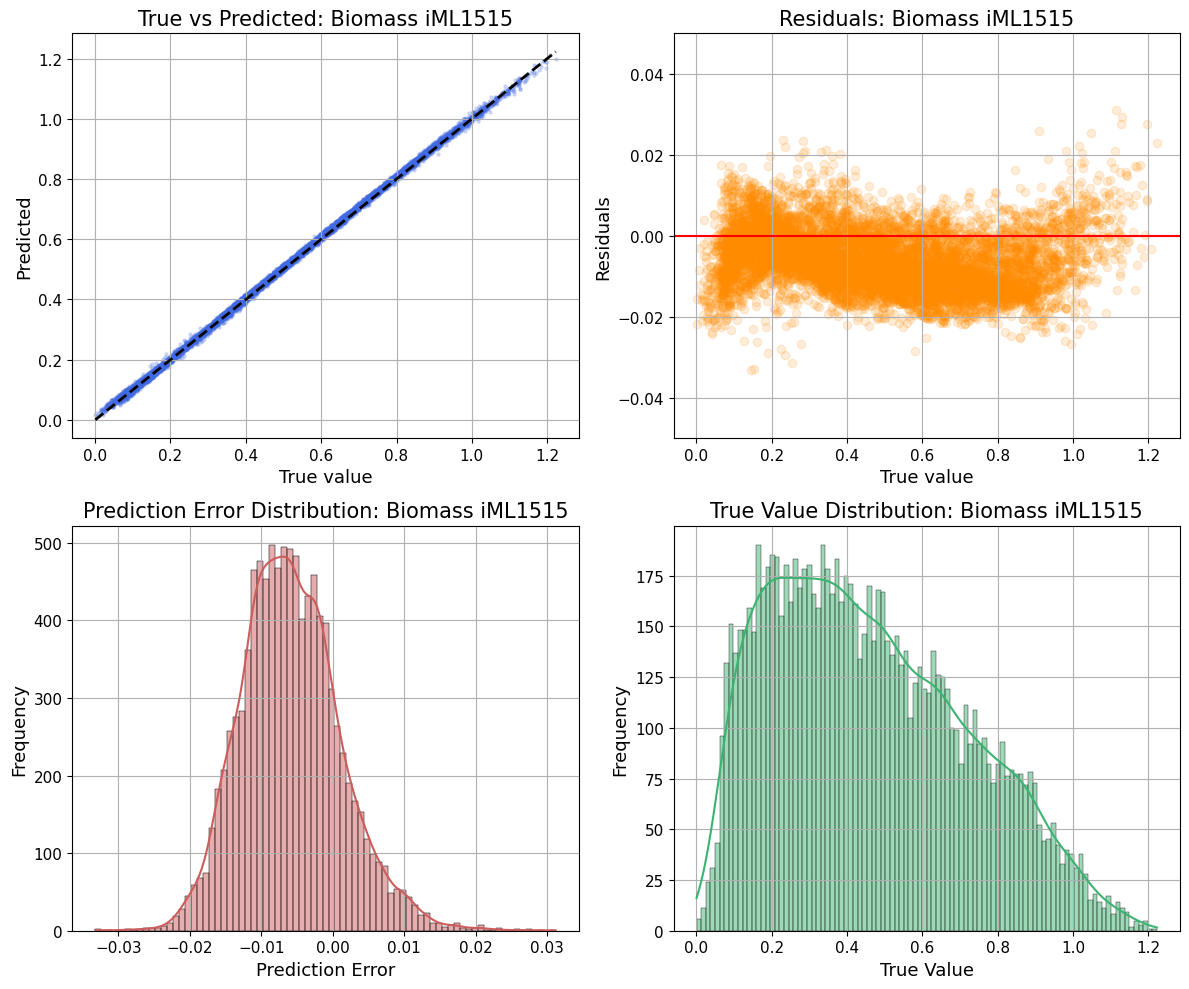

In [16]:
diagnostics_to_plot = ['BIOMASS_Ec_iML1515_WT_75p37M_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=save_path)

EX_glc__D_e_flux:
------------------------------------------------------------
EX_glc__D_e_flux token index: 180
injected medium slot: True
y_true range: -15.0 to -1.0
y_pred range: -15.20392894744873 to -1.03523588180542
R2: 0.9999
MAE: 0.025364
RMSE: 0.041918


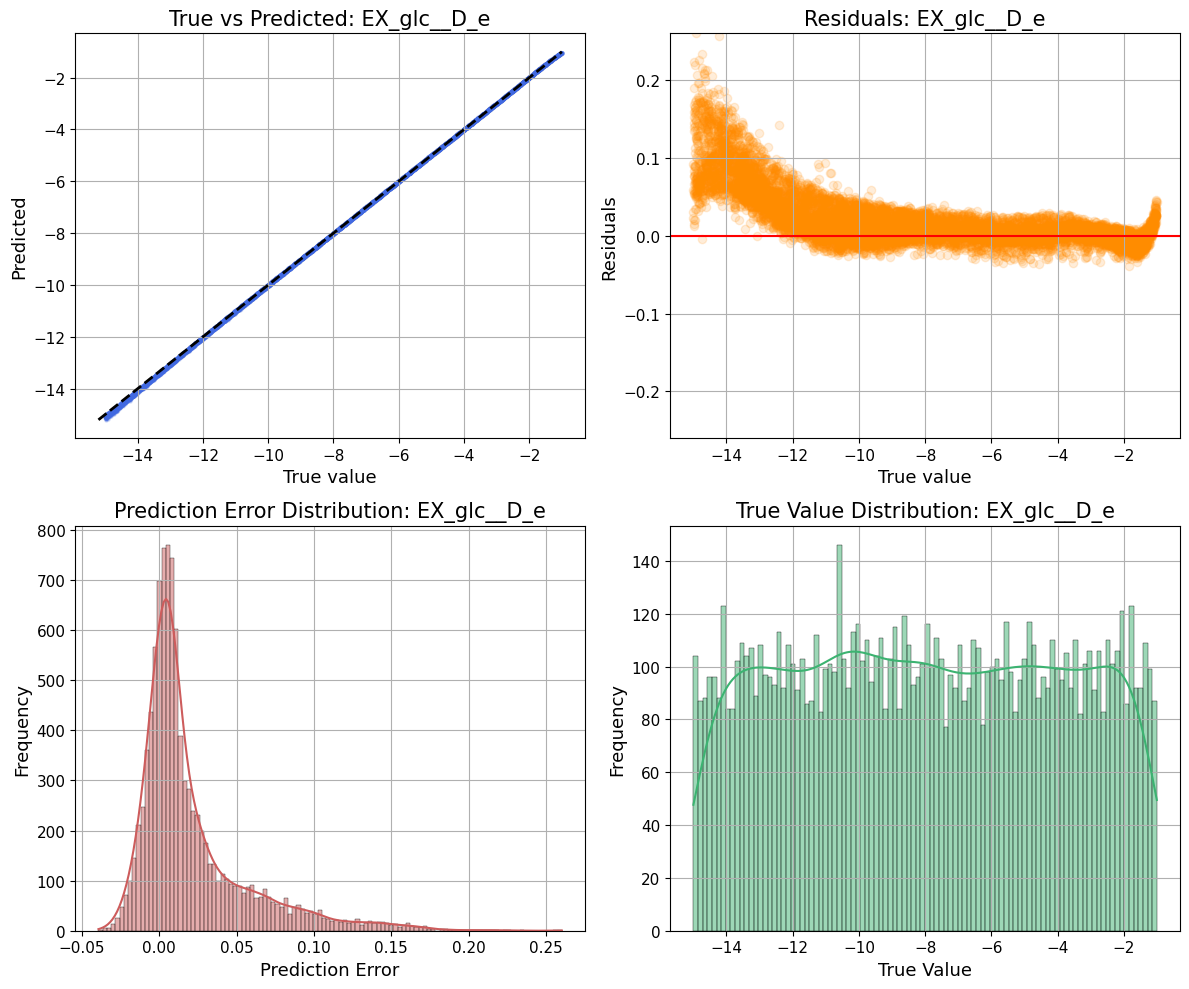

EX_o2_e_flux:
------------------------------------------------------------
EX_o2_e_flux token index: 1981
injected medium slot: True
y_true range: -29.798036575317383 to -1.0
y_pred range: -30.327390670776367 to -1.0192625522613525
R2: 0.9990
MAE: 0.159355
RMSE: 0.209882


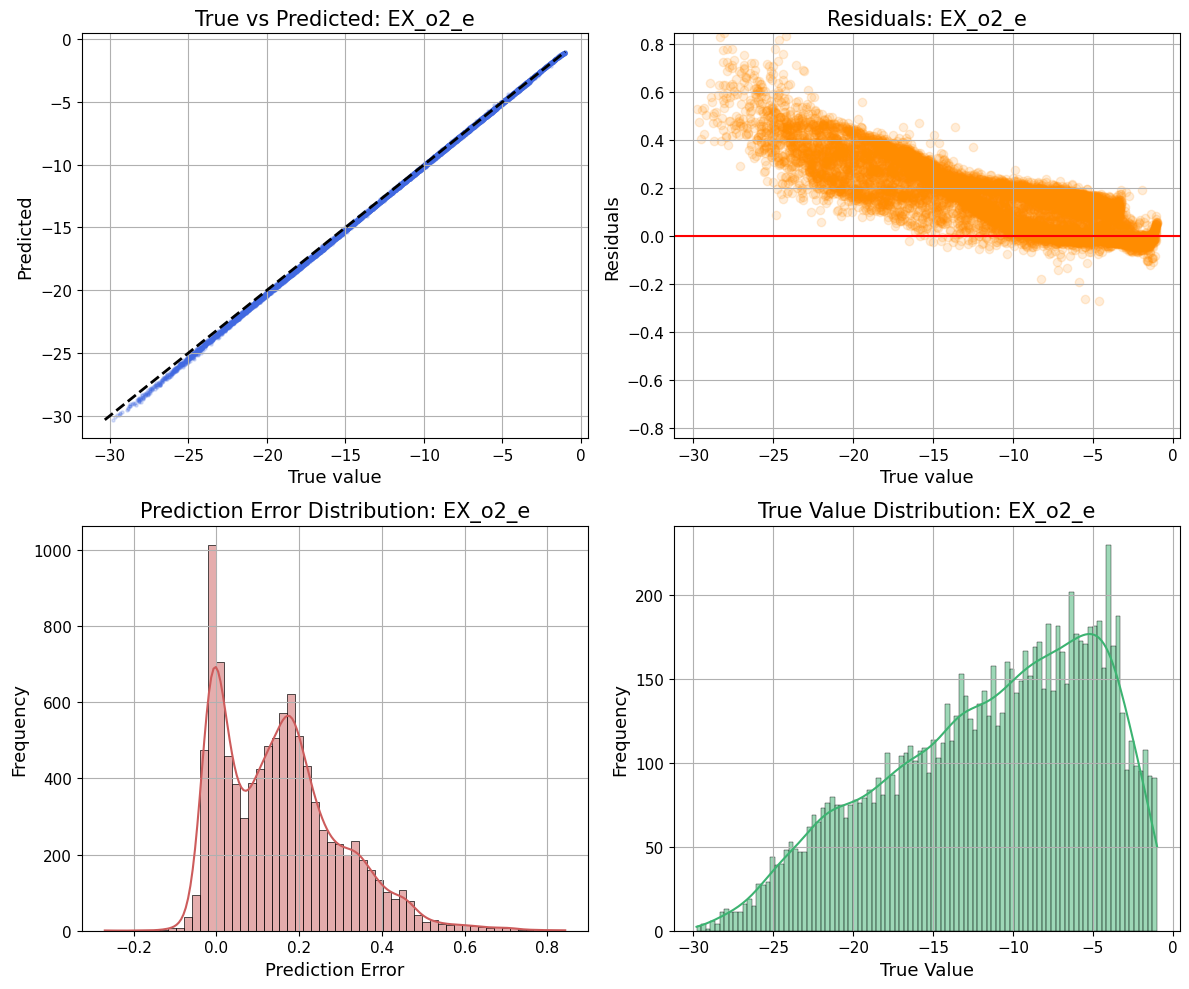

EX_co2_e_flux:
------------------------------------------------------------
EX_co2_e_flux token index: 45
injected medium slot: True
y_true range: 0.0 to 29.872682571411133
y_pred range: 0.002497434616088867 to 29.475160598754883
R2: 0.9998
MAE: 0.063243
RMSE: 0.084483


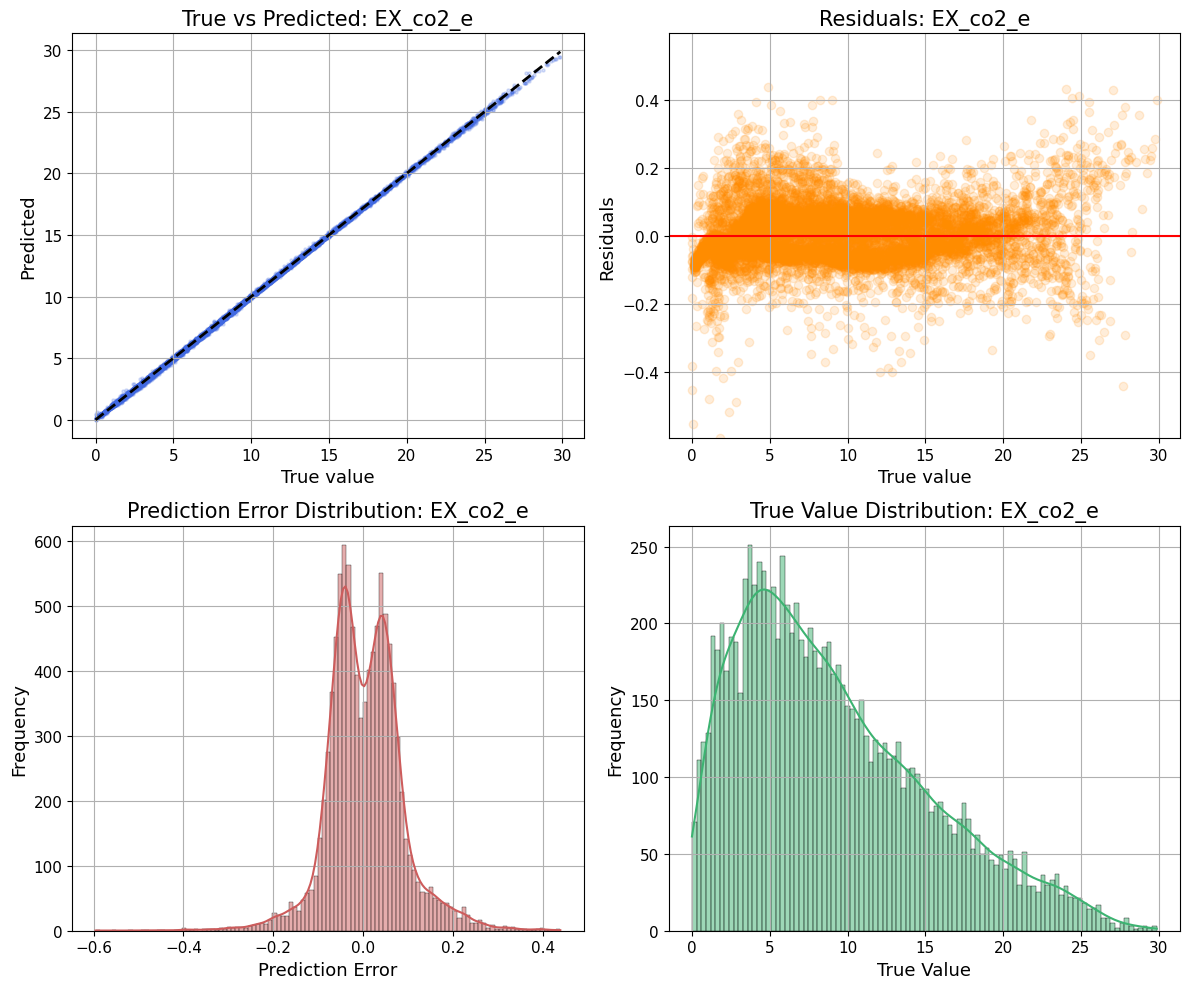

EX_etoh_e_flux:
------------------------------------------------------------
EX_etoh_e_flux token index: 1525
injected medium slot: True
y_true range: -1.6645101108366216e-18 to 0.8930307030677795
y_pred range: -0.0007284730672836304 to 0.010128691792488098
R2: -0.5444
MAE: 0.007376
RMSE: 0.012112


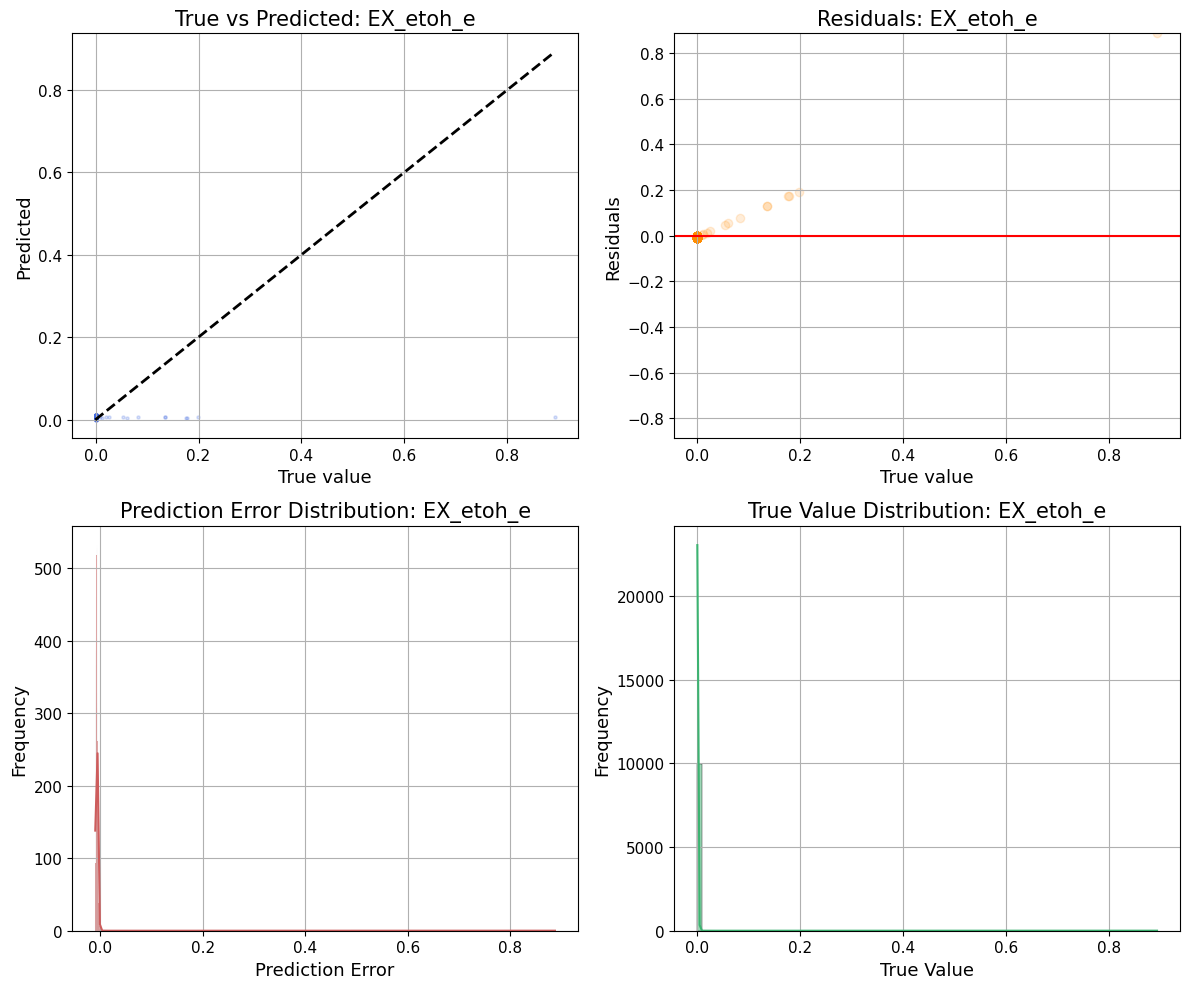

EX_ac_e_flux:
------------------------------------------------------------
EX_ac_e_flux token index: 106
injected medium slot: True
y_true range: 0.0 to 3.990000009536743
y_pred range: -0.039507508277893066 to 4.167404651641846
R2: 0.9947
MAE: 0.019807
RMSE: 0.043536


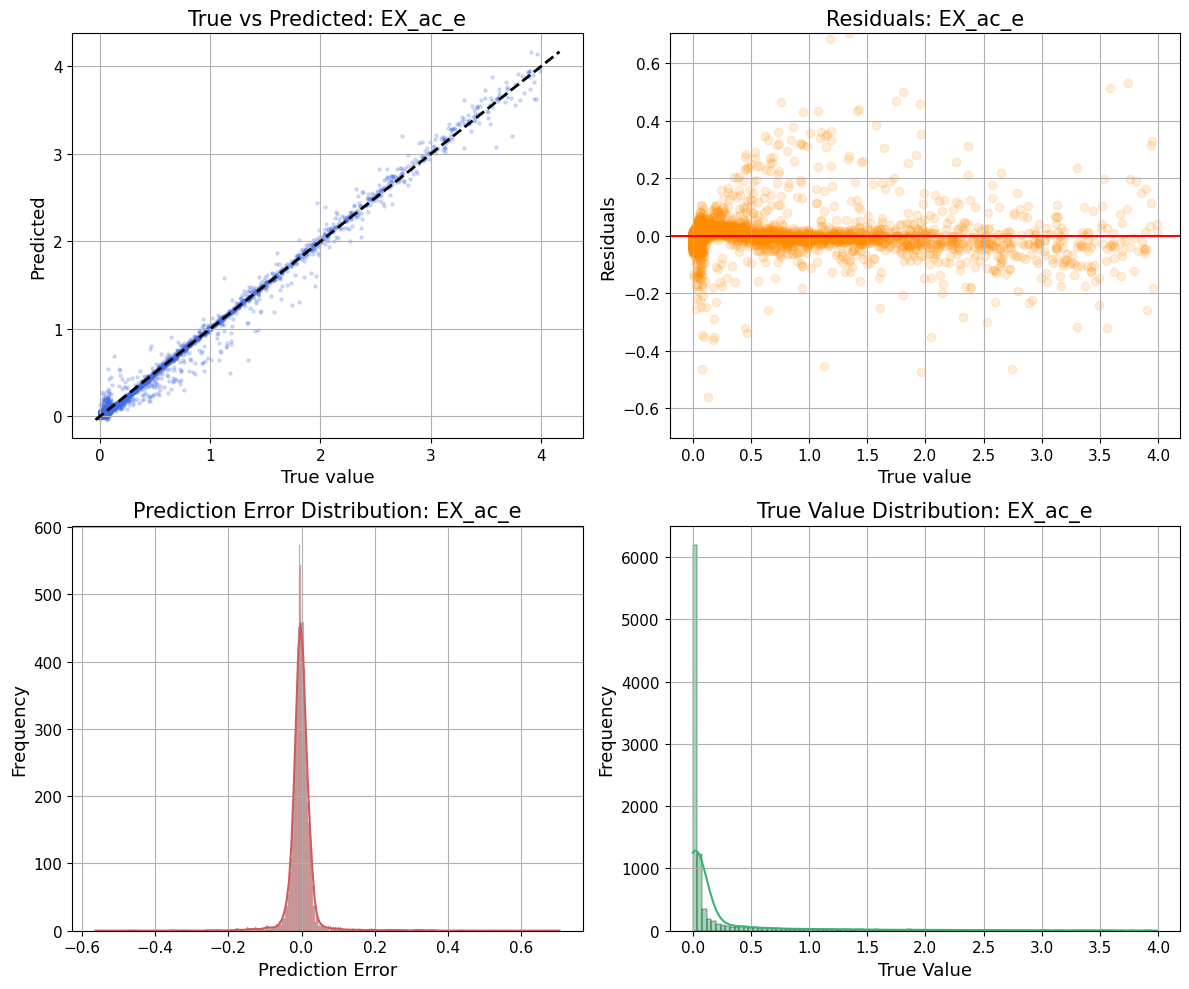

In [17]:
# Diagnostic plots for the 5 MINN target fluxes
target_fluxes_5 = [
    'EX_glc__D_e_flux',
    'EX_o2_e_flux',
    'EX_co2_e_flux',
    'EX_etoh_e_flux',
    'EX_ac_e_flux',
]

for flux_name in target_fluxes_5:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)


GLUDy_flux:
------------------------------------------------------------
GLUDy_flux token index: 1404
injected medium slot: False
y_true range: -10.236693382263184 to -0.003137128194794059
y_pred range: -10.191267013549805 to -0.0010273456573486328
R2: 0.9993
MAE: 0.050154
RMSE: 0.056386


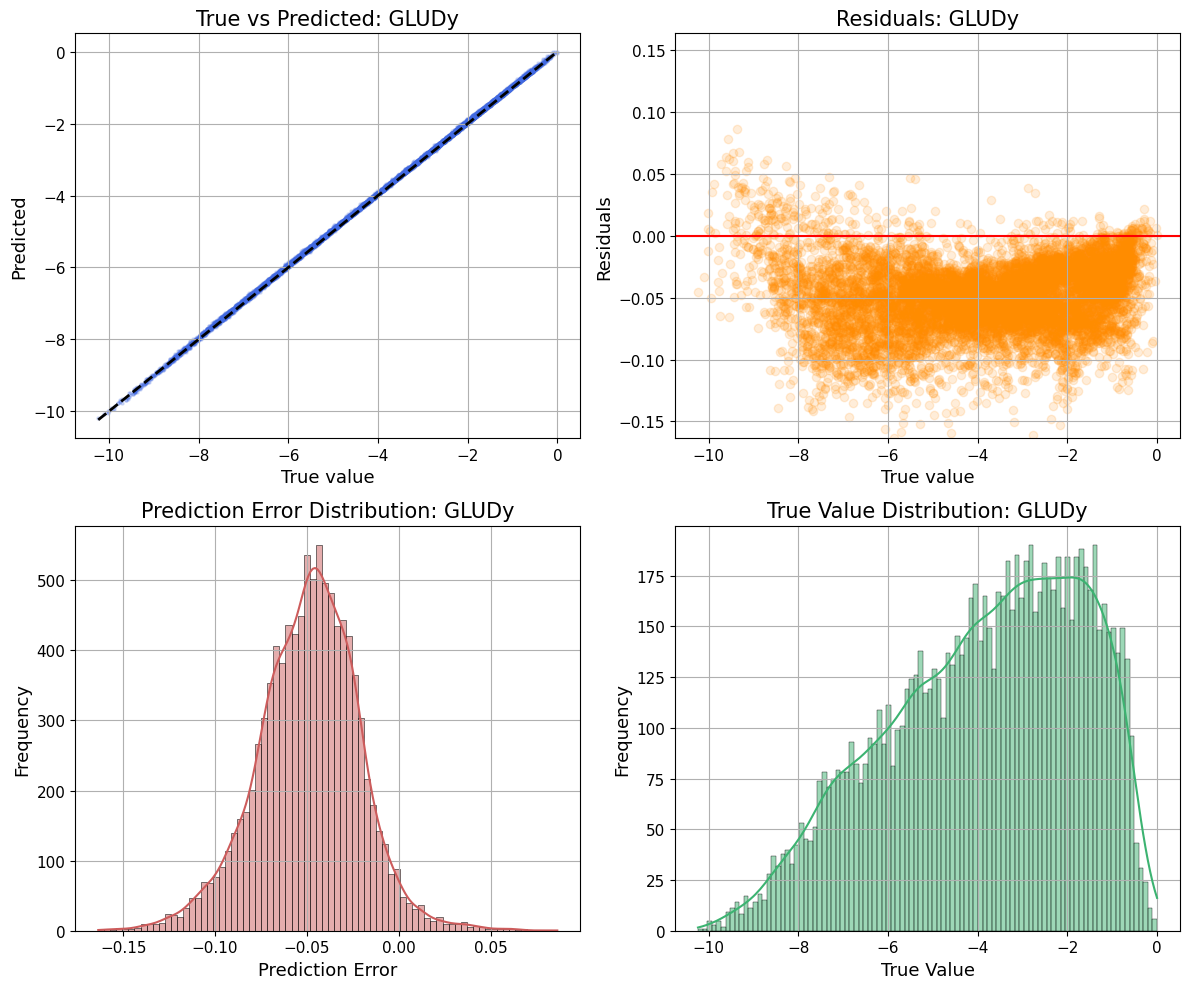

H2Otpp_flux:
------------------------------------------------------------
H2Otpp_flux token index: 1362
injected medium slot: False
y_true range: -63.72446823120117 to -0.5201561450958252
y_pred range: -62.62234878540039 to -1.0749328136444092
R2: 0.9995
MAE: 0.251224
RMSE: 0.282608


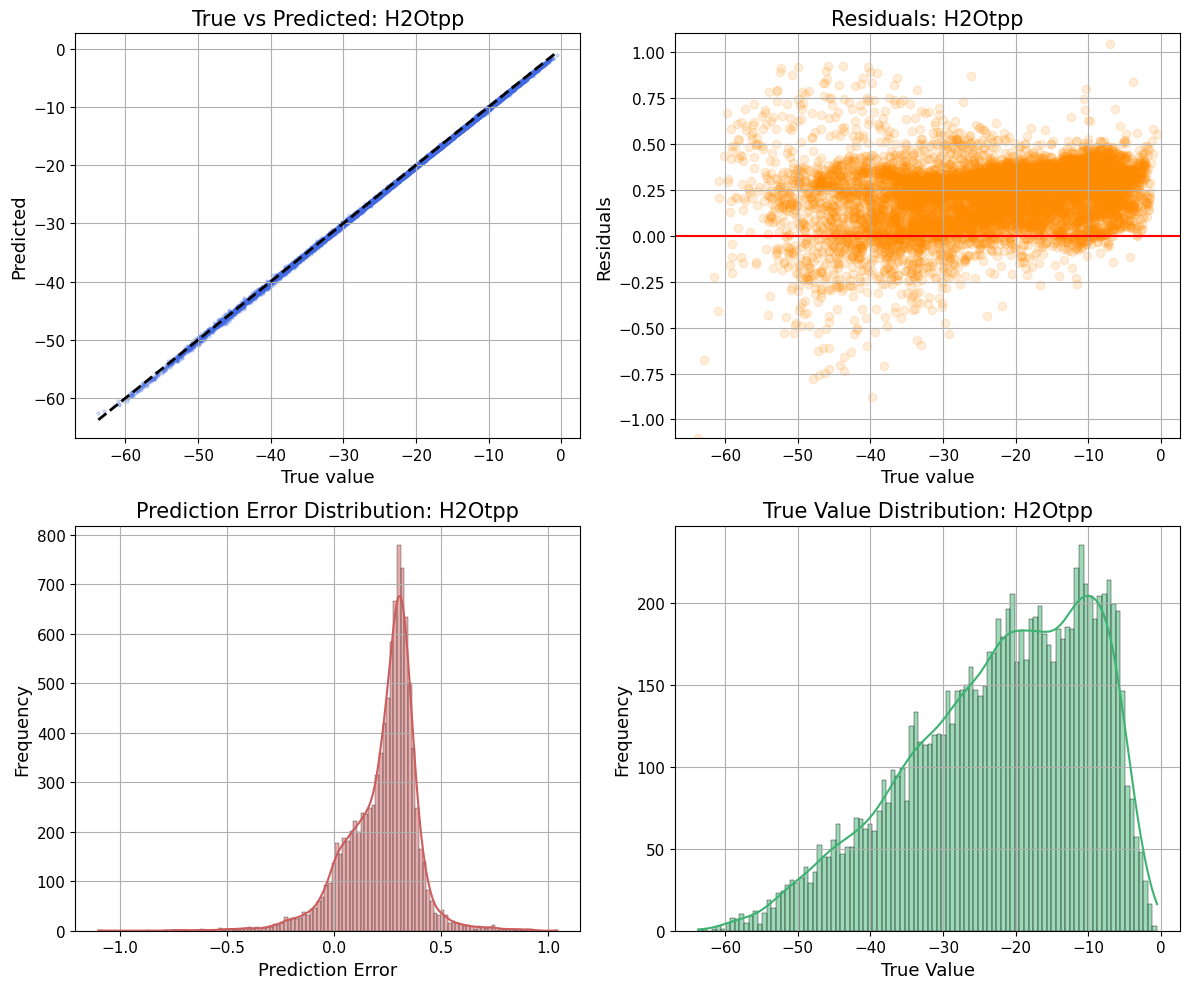

In [18]:
diagnostics_to_plot = ['GLUDy_flux', 'H2Otpp_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)

In [19]:
# Overall model metrics across all output fluxes (flattened)
def _compute_overall_metrics(model_ref, X_ref, y_ref, outputs_ref, device_ref, batch_size_ref):
    model_eval = model_ref.to(device_ref).eval()
    V = len(outputs_ref)

    if X_ref.shape[1] != V or y_ref.shape[1] != V:
        raise ValueError(
            f"Expected X_test/y_test second dim == len(outputs)={V}, got {X_ref.shape[1]} and {y_ref.shape[1]}"
        )

    pred_batches = []
    true_batches = []
    perm = None
    use_amp = device_ref.type == "cuda"

    with torch.inference_mode():
        for i in range(0, X_ref.shape[0], batch_size_ref):
            xb = X_ref[i:i + batch_size_ref].to(device_ref)
            yb_true = y_ref[i:i + batch_size_ref]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)
            else:
                preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)

            preds_last = preds_all_layers[:, :, -1]  # (B, S)

            if perm is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                selected_indices_np = selected_indices_np.astype(int)

                if selected_indices_np.size != V:
                    raise RuntimeError(f"Model returned {selected_indices_np.size} outputs, expected {V}.")

                inv = np.full(V, -1, dtype=np.int64)
                inv[selected_indices_np] = np.arange(selected_indices_np.size, dtype=np.int64)
                if (inv < 0).any():
                    missing = np.where(inv < 0)[0].tolist()
                    raise RuntimeError(f"Missing output indices in model forward pass: {missing[:10]}")
                perm = torch.as_tensor(inv, device=preds_last.device, dtype=torch.long)

            yb_pred = preds_last.index_select(1, perm).detach().cpu().numpy().astype(np.float32, copy=False)
            pred_batches.append(yb_pred)
            true_batches.append(yb_true.detach().cpu().numpy().astype(np.float32, copy=False))

            del xb, preds_all_layers, preds_last, selected_indices
            if device_ref.type == "cuda":
                torch.cuda.empty_cache()

    y_pred_full = np.concatenate(pred_batches, axis=0)
    y_true_full = np.concatenate(true_batches, axis=0)

    overall_r2 = r2_score(y_true_full.ravel(), y_pred_full.ravel())
    overall_mae = mean_absolute_error(y_true_full.ravel(), y_pred_full.ravel())
    overall_rmse = root_mean_squared_error(y_true_full.ravel(), y_pred_full.ravel())
    return overall_r2, overall_mae, overall_rmse

original_device = next(model.parameters()).device
preferred_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if preferred_device.type == "cuda":
    batch_size_metrics = 2
else:
    batch_size_metrics = 32

used_device = preferred_device
try:
    overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
        model, X_test, y_test, outputs, preferred_device, batch_size_metrics
    )
except RuntimeError as e:
    if preferred_device.type == "cuda" and "out of memory" in str(e).lower():
        print("CUDA OOM during overall metrics; falling back to CPU...")
        torch.cuda.empty_cache()
        used_device = torch.device("cpu")
        overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
            model, X_test, y_test, outputs, used_device, 32
        )
    else:
        raise
finally:
    model.to(original_device)

print("Overall model metrics (all fluxes, flattened):")
print(f"Device used: {used_device}")
print(f"R2:   {overall_r2:.4f}")
print(f"MAE:  {overall_mae:.6f}")
print(f"RMSE: {overall_rmse:.6f}")

Overall model metrics (all fluxes, flattened):
Device used: cuda
R2:   0.9998
MAE:  0.006096
RMSE: 0.025891


### FluxTransformer Reservoir Training

This section trains the front MLP that feeds the frozen FluxTransformer reservoir.

This mirrors the MINN repository's reservoir training structure: transcriptomics, proteomics, and measured glucose/oxygen uptake are merged into the front-MLP input matrix. The trainable front MLP maps those inputs to a five-value reservoir vector, and that five-value vector is passed to the frozen pretrained block. In this notebook, the frozen pretrained block is FluxTransformer using the unsplit, unpruned iML1515 reaction/token vocabulary.

Measured glucose and oxygen are therefore inputs to the front MLP, not values copied directly into the FluxTransformer input vector. FluxTransformer still receives a full vocabulary-sized input vector: the five reservoir-context positions are filled with front-MLP predictions for glucose, oxygen, CO2, ethanol, and acetate; the configured base-exchange positions are filled with fixed medium/background values; all remaining positions are set to zero.

The downstream pFBA evaluation is a separate comparison step. The baseline pFBA row uses only measured glucose and oxygen uptake as constraints. The FluxTransformer + pFBA row uses the same measured glucose and oxygen constraints, and additionally constrains CO2, ethanol, and acetate using out-of-fold front-MLP predictions.


In [20]:
from pathlib import Path


def _minn_to_flux_token(rxn_name: str, outputs_vocab):
    """Map MINN reaction naming to FluxTransformer token names (+ sign conversion for *_rev)."""
    if rxn_name.startswith("R_BIOMASS"):
        if "BIOMASS_Ec_iML1515_WT_75p37M_flux" in outputs_vocab:
            return "BIOMASS_Ec_iML1515_WT_75p37M_flux", 1.0
        if "BIOMASS_Ec_iML1515_core_75p37M_flux" in outputs_vocab:
            return "BIOMASS_Ec_iML1515_core_75p37M_flux", 1.0

    base = rxn_name
    if base.startswith("R_"):
        base = base[2:]

    sign = 1.0
    if base.endswith("_fwd"):
        base = base[:-4]
    elif base.endswith("_rev"):
        base = base[:-4]
        sign = -1.0

    tok = f"{base}_flux"
    if tok in outputs_vocab:
        return tok, sign
    return None, None


# ----- FluxTransformer reservoir settings -----
MINN_DATA_DIR = "./MINN_data"
MINN_FLUXOMICS_FILE = "fluxomics_iAF1260_reduced_split_fit.csv"

# 2 measured medium inputs (same as MINN dataset config)
MINN_INPUT_FLUX_COLS = ["R_EX_glc__D_e_rev", "R_EX_o2_e_rev"]
MINN_MEASURED_CONTEXT_SOURCE = list(MINN_INPUT_FLUX_COLS)

# CO2/ethanol/acetate are the learned extra constraints used later by FluxTransformer + pFBA.
MINN_LEARNED_CONSTRAINT_SOURCE = [
    "R_EX_co2_e_fwd",
    "R_EX_etoh_e",
    "R_EX_ac_e",
]

# Full 5-channel reservoir context passed into FluxTransformer.
MINN_RESERVOIR_CONTEXT_SOURCE = MINN_MEASURED_CONTEXT_SOURCE + MINN_LEARNED_CONSTRAINT_SOURCE

# base_exchanges from generate_ecoli_iML1515_MINN_data.py
BASE_EXCHANGES = [
    "EX_pi_e",
    "EX_co2_e",
    "EX_h_e",
    "EX_mn2_e",
    "EX_fe2_e",
    "EX_zn2_e",
    "EX_mg2_e",
    "EX_ca2_e",
    "EX_ni2_e",
    "EX_cu2_e",
    "EX_cobalt2_e",
    "EX_h2o_e",
    "EX_mobd_e",
    "EX_so4_e",
    "EX_nh4_e",
    "EX_k_e",
    "EX_na1_e",
    "EX_cl_e",
    "EX_o2_e",
    "EX_fe3_e",
    "EX_sel_e",
    "EX_tungs_e",
    "EX_slnt_e",
    "EX_cbl1_e",
]
DEFAULT_BASE_EXCHANGE_RATE = 50.0


def load_minn_omics_for_reservoir(data_dir: str, outputs_vocab):
    """
    Load MINN-style input (omics + 2 measured fluxes) and build the 5-channel
    reservoir context labels mapped into FluxTransformer token space.
    """
    data_dir_p = Path(data_dir)
    transcript_path = data_dir_p / "transcriptomics.csv"
    proteomics_path = data_dir_p / "proteomics.csv"
    fluxomics_path = data_dir_p / MINN_FLUXOMICS_FILE

    if not transcript_path.exists() or not proteomics_path.exists() or not fluxomics_path.exists():
        raise FileNotFoundError(
            f"Expected MINN files in {data_dir}: transcriptomics.csv, proteomics.csv, {MINN_FLUXOMICS_FILE}"
        )

    tr = pd.read_csv(transcript_path)
    pr = pd.read_csv(proteomics_path)
    fl = pd.read_csv(fluxomics_path)

    # MINN-style merge
    x_df = tr.merge(pr, on="experiment", how="left")

    missing_input = [c for c in MINN_INPUT_FLUX_COLS if c not in fl.columns]
    if missing_input:
        raise ValueError(f"Missing MINN input flux columns: {missing_input}")

    x_df = x_df.merge(fl[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
    x_df = x_df[x_df["experiment"].isin(fl["experiment"])].reset_index(drop=True)

    fl_idx = fl.set_index("experiment")

    mapped = []  # (source_col, token_name, token_idx, sign)
    for source_col in MINN_RESERVOIR_CONTEXT_SOURCE:
        if source_col not in fl.columns:
            raise ValueError(f"Missing target source column in fluxomics file: {source_col}")
        tok, sign = _minn_to_flux_token(source_col, outputs_vocab)
        if tok is None:
            raise RuntimeError(f"Could not map {source_col} into FluxTransformer token vocabulary")
        mapped.append((source_col, tok, outputs_vocab.index(tok), sign))

    # Inputs
    x_features = [c for c in x_df.columns if c != "experiment"]
    X_np = x_df[x_features].to_numpy(dtype=np.float32)

    # Targets/context labels (5), mapped with sign for FluxTransformer output-space loss.
    experiments = x_df["experiment"].tolist()
    y_rows = []
    for exp in experiments:
        row = []
        for src, _tok, _idx, sign in mapped:
            row.append(float(fl_idx.at[exp, src]) * sign)
        y_rows.append(row)

    y_np = np.asarray(y_rows, dtype=np.float32)

    target_token_names = [tok for _src, tok, _idx, _sign in mapped]
    target_token_indices = [idx for _src, _tok, idx, _sign in mapped]

    return X_np, y_np, x_features, target_token_names, target_token_indices, mapped, experiments


(
    X_minn_np,
    y_minn_np,
    minn_feature_names,
    minn_target_token_names,
    minn_target_indices,
    minn_mapped_sources,
    minn_experiments,
) = load_minn_omics_for_reservoir(
    data_dir=MINN_DATA_DIR,
    outputs_vocab=outputs,
)

minn_target_indices_t = torch.tensor(minn_target_indices, dtype=torch.long, device=device)
# Signs used in MINN source naming (*_rev -> -1). Needed to recover positive constraint magnitudes for front-MLP supervision.
minn_target_signs = np.asarray([float(sign) for _src, _tok, _idx, sign in minn_mapped_sources], dtype=np.float32)
minn_target_signs_t = torch.tensor(minn_target_signs, dtype=torch.float32, device=device)

minn_source_to_context_position = {src: i for i, (src, _tok, _idx, _sign) in enumerate(minn_mapped_sources)}
minn_mapped_by_source = {src: (tok, idx, sign) for src, tok, idx, sign in minn_mapped_sources}
minn_learned_context_positions = [minn_source_to_context_position[src] for src in MINN_LEARNED_CONSTRAINT_SOURCE]
minn_learned_context_positions_t = torch.tensor(minn_learned_context_positions, dtype=torch.long, device=device)
minn_learned_token_names = [minn_mapped_by_source[src][0] for src in MINN_LEARNED_CONSTRAINT_SOURCE]
minn_measured_token_names = [minn_mapped_by_source[src][0] for src in MINN_MEASURED_CONTEXT_SOURCE]
minn_measured_feature_indices = [minn_feature_names.index(src) for src in MINN_MEASURED_CONTEXT_SOURCE]

# Build fixed base exchange constraints in FluxTransformer token space.
# Rules for the full input vector assembled inside the wrapper:
# - the 5 reservoir-context token positions are filled from front-MLP predictions
# - base_exchanges outside those 5 context tokens are fixed at DEFAULT_BASE_EXCHANGE_RATE
# - all other token positions are zero
context_token_set = set(minn_target_token_names)
fixed_base_token_values = {}
for ex in BASE_EXCHANGES:
    tok = f"{ex}_flux"
    if tok in outputs and tok not in context_token_set:
        fixed_base_token_values[tok] = float(DEFAULT_BASE_EXCHANGE_RATE)


class FrozenFluxTransformerWithMLP(nn.Module):
    """
    FluxTransformer reservoir wrapper:
    - Front MLP predicts the full 5-channel reservoir context
    - Full FluxTransformer input vector is assembled as:
        predicted 5 + fixed base_exchanges + zeros elsewhere
    - Frozen pretrained FluxTransformer

    pFBA evaluation later keeps measured glucose/oxygen measured and uses only
    the predicted CO2/ethanol/acetate channels as additional constraints.
    """
    def __init__(
        self,
        flux_transformer: nn.Module,
        input_dim: int,
        predicted_token_names,
        fixed_base_token_values,
        hidden_dim: int = 512,
        drop_rate: float = 0.25,
    ):
        super().__init__()
        self.frozen_flux_transformer = flux_transformer
        self.vocab_size = int(self.frozen_flux_transformer.vocab_size)

        self.predicted_token_names = list(predicted_token_names)
        self.fixed_base_token_values = dict(fixed_base_token_values)

        token_to_idx = {tok: i for i, tok in enumerate(outputs)}
        pred_indices = []
        for tok in self.predicted_token_names:
            if tok not in token_to_idx:
                raise ValueError(f"Predicted token not found in outputs vocab: {tok}")
            pred_indices.append(token_to_idx[tok])

        fixed_names = []
        fixed_vals = []
        for tok, val in self.fixed_base_token_values.items():
            if tok in token_to_idx:
                fixed_names.append(tok)
                fixed_vals.append(float(val))

        self.register_buffer("predicted_indices", torch.tensor(pred_indices, dtype=torch.long), persistent=True)
        self.register_buffer("fixed_indices", torch.tensor([token_to_idx[t] for t in fixed_names], dtype=torch.long), persistent=True)
        self.register_buffer("fixed_values", torch.tensor(fixed_vals, dtype=torch.float32), persistent=True)

        for p in self.frozen_flux_transformer.parameters():
            p.requires_grad = False
        self.frozen_flux_transformer.eval()

        # Predict exactly the 5 channels used by the pretrained reservoir block.
        self.front_mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(hidden_dim, len(self.predicted_token_names)),
        )

    def train(self, mode: bool = True):
        super().train(mode)
        self.frozen_flux_transformer.eval()
        return self

    def build_full_input_vector(self, x):
        # x: [B, n_features]
        pred_raw = self.front_mlp(x)  # [B, 5]
        pred_vals = F.softplus(pred_raw)  # keep constraints non-negative

        B = x.size(0)
        c0 = torch.zeros(B, self.vocab_size, dtype=x.dtype, device=x.device)

        if self.fixed_indices.numel() > 0:
            c0[:, self.fixed_indices] = self.fixed_values.to(dtype=x.dtype, device=x.device).unsqueeze(0)

        c0[:, self.predicted_indices] = pred_vals
        return c0

    def forward(self, x, output_subset=None, return_embedding=False):
        if x.dim() == 3 and x.size(-1) == 1:
            x = x.squeeze(-1)
        c0 = self.build_full_input_vector(x).unsqueeze(-1)
        return self.frozen_flux_transformer(c0, output_subset=output_subset, return_embedding=return_embedding)


# Build model
minn_model = FrozenFluxTransformerWithMLP(
    flux_transformer=model,
    input_dim=X_minn_np.shape[1],
    predicted_token_names=minn_target_token_names,
    fixed_base_token_values=fixed_base_token_values,
    hidden_dim=512,
    drop_rate=0.25,
).to(device)

with torch.no_grad():
    _x2 = torch.tensor(X_minn_np[:2], dtype=torch.float32, device=device)
    _c0_sanity = minn_model.build_full_input_vector(_x2)
    _pred_sanity, _sel_sanity = minn_model(_x2, output_subset=None)

trainable_params = sum(p.numel() for p in minn_model.parameters() if p.requires_grad)
frozen_flux_params = sum(p.numel() for p in minn_model.frozen_flux_transformer.parameters() if not p.requires_grad)

print("Loaded MINN-style omics dataset")
print(f"MINN data dir: {MINN_DATA_DIR}")
print(f"Samples: {X_minn_np.shape[0]}")
print(f"Input features (omics + 2 measured fluxes): {X_minn_np.shape[1]}")
print("Measured context flux columns:", MINN_MEASURED_CONTEXT_SOURCE)
print("5 front-MLP reservoir context source fluxes:", MINN_RESERVOIR_CONTEXT_SOURCE)
print("pFBA extra predicted constraints:", MINN_LEARNED_CONSTRAINT_SOURCE)
print("Mapped context token names:", minn_target_token_names)
print("MINN source -> FluxTransformer token mapping (with sign)")
for src, tok, idx, sign in minn_mapped_sources:
    print(f"  {src:>18} -> {tok:<20} idx={idx:4d} sign={sign:+.0f}")
print("Measured input feature positions:", dict(zip(MINN_MEASURED_CONTEXT_SOURCE, minn_measured_feature_indices)))
print(f"Fixed base exchange token count: {len(fixed_base_token_values)} (value={DEFAULT_BASE_EXCHANGE_RATE})")
print(f"Trainable params (front MLP only): {trainable_params:,}")
print(f"Frozen FluxTransformer params:      {frozen_flux_params:,}")
print(f"Sanity c0 shape:                   {tuple(_c0_sanity.shape)}")
print(f"Sanity transformer output shape:   {tuple(_pred_sanity.shape)}")


Loaded MINN-style omics dataset
MINN data dir: ./MINN_data
Samples: 29
Input features (omics + 2 measured fluxes): 141
Measured context flux columns: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
5 front-MLP reservoir context source fluxes: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev', 'R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
pFBA extra predicted constraints: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
Mapped context token names: ['EX_glc__D_e_flux', 'EX_o2_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_ac_e_flux']
MINN source -> FluxTransformer token mapping (with sign)
   R_EX_glc__D_e_rev -> EX_glc__D_e_flux     idx= 180 sign=-1
       R_EX_o2_e_rev -> EX_o2_e_flux         idx=1981 sign=-1
      R_EX_co2_e_fwd -> EX_co2_e_flux        idx=  45 sign=+1
         R_EX_etoh_e -> EX_etoh_e_flux       idx=1525 sign=+1
           R_EX_ac_e -> EX_ac_e_flux         idx= 106 sign=+1
Measured input feature positions: {'R_EX_glc__D_e_rev': 139, 'R_EX_o2_e_rev': 140}
Fixed base exchange token count: 2

In [21]:
# Assertions: token/reaction mapping and sign conventions for MINN -> iML1515 integration

import xml.etree.ElementTree as ET
from pathlib import Path

# 1) Required predicted tokens must exist in outputs vocab
required_pred_tokens = [
    "EX_glc__D_e_flux",
    "EX_o2_e_flux",
    "EX_co2_e_flux",
    "EX_etoh_e_flux",
    "EX_ac_e_flux",
]

missing_pred_tokens = [t for t in required_pred_tokens if t not in outputs]
assert not missing_pred_tokens, (
    "Missing required predicted tokens in outputs vocab: "
    + ", ".join(missing_pred_tokens)
)

# 2) Base exchange tokens must exist in outputs vocab
base_tokens = [f"{ex}_flux" for ex in BASE_EXCHANGES]
missing_base_tokens = [t for t in base_tokens if t not in outputs]
assert not missing_base_tokens, (
    "Missing base exchange tokens in outputs vocab: "
    + ", ".join(missing_base_tokens)
)

# 3) pFBA-constrained reactions must exist in iML1515 model
model_path = Path("./models/iML1515.xml")
assert model_path.exists(), f"SBML model not found: {model_path}"

ns = {"sbml": "http://www.sbml.org/sbml/level3/version1/core"}
root = ET.parse(model_path).getroot()
rxn_ids = [r.attrib.get("id", "") for r in root.findall('.//sbml:listOfReactions/sbml:reaction', ns)]
rxn_ids_norm = {(rid[2:] if rid.startswith("R_") else rid) for rid in rxn_ids}

required_pfba_rxns = ["EX_glc__D_e", "EX_o2_e", "EX_co2_e", "EX_etoh_e", "EX_ac_e"]
missing_rxns = [r for r in required_pfba_rxns if r not in rxn_ids_norm]
assert not missing_rxns, "Missing required pFBA reactions in iML1515 model: " + ", ".join(missing_rxns)

# 4) MINN context columns used as FluxTransformer input constraints should be nonnegative magnitudes
fluxomics_path = Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE
assert fluxomics_path.exists(), f"Fluxomics file not found: {fluxomics_path}"

fl_check = pd.read_csv(fluxomics_path)
for col in MINN_RESERVOIR_CONTEXT_SOURCE:
    assert col in fl_check.columns, f"Expected sign-check column missing: {col}"
    cmin = float(fl_check[col].min())
    assert cmin >= -1e-9, f"Column {col} has negative values (min={cmin}), sign assumption broken."

# 5) Explicitly lock the reservoir-context source -> iML1515 token/sign mapping.
expected_context_mapping = {
    "R_EX_glc__D_e_rev": ("EX_glc__D_e_flux", -1.0),
    "R_EX_o2_e_rev": ("EX_o2_e_flux", -1.0),
    "R_EX_co2_e_fwd": ("EX_co2_e_flux", 1.0),
    "R_EX_etoh_e": ("EX_etoh_e_flux", 1.0),
    "R_EX_ac_e": ("EX_ac_e_flux", 1.0),
}
observed_context_mapping = {src: (tok, float(sign)) for src, tok, _idx, sign in minn_mapped_sources}
assert observed_context_mapping == expected_context_mapping, (
    "Unexpected reservoir-context mapping/signs: " + str(observed_context_mapping)
)

# 6) Mapping coverage sanity for measured flux columns used in metrics
metric_source_cols = [c for c in fl_check.columns if c != "experiment"]
unmapped = []
for src in metric_source_cols:
    tok, sign = _minn_to_flux_token(src, outputs)
    if tok is None:
        unmapped.append(src)
    else:
        assert sign in (-1.0, 1.0), f"Unexpected sign {sign} for {src}"

assert not unmapped, "Some measured flux columns could not map into iML1515 token space: " + ", ".join(unmapped[:20])

print("Assertions passed: token existence, reaction existence, mapping coverage, and sign conventions are consistent.")


Assertions passed: token existence, reaction existence, mapping coverage, and sign conventions are consistent.


c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-13 09:45:40,463] A new study created in memory with name: no-name-06519a49-074f-4355-abf2-856f3f322f3b


CUDA detected: overriding batch_size 5 -> 2 to avoid OOM with full-output forward.
Aux-loss sweep configuration
  weights: [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
  HPO once: True
  redo HPO per aux weight: False
Running one-time global HPO on full dataset...


[I 2026-05-13 09:52:14,223] Trial 0 finished with value: 1.4605930680316832 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.0002779786839270331, 'weight_decay': 5.048647944386168e-05}. Best is trial 0 with value: 1.4605930680316832.
[I 2026-05-13 09:57:51,810] Trial 1 finished with value: 1.2805622628529005 and parameters: {'drop_rate': 0.25, 'learning_rate': 0.0006675645581108722, 'weight_decay': 9.135022314418179e-05}. Best is trial 1 with value: 1.2805622628529005.
[I 2026-05-13 10:04:58,112] Trial 2 finished with value: 1.4208339933974954 and parameters: {'drop_rate': 0.25, 'learning_rate': 0.00023737305658044986, 'weight_decay': 7.872472301830258e-06}. Best is trial 1 with value: 1.2805622628529005.
[I 2026-05-13 10:10:59,565] Trial 3 finished with value: 1.2226152082435897 and parameters: {'drop_rate': 0.5, 'learning_rate': 0.0009446908979744113, 'weight_decay': 0.00014827093995744075}. Best is trial 3 with value: 1.2226152082435897.
[I 2026-05-13 10:17:04,910] Trial 4 fini

HPO completed for aux_weight=1.0: 50/50 trials attempted (50 completed)
Best hyperparameters after trials: {'drop_rate': 0.25, 'learning_rate': 0.0009736777696601047, 'weight_decay': 4.738391288843704e-05}
Best inner_cv_objective after trials: 1.112212
Global best_params (anchor aux=1.0): {'drop_rate': 0.25, 'learning_rate': 0.0009736777696601047, 'weight_decay': 4.738391288843704e-05}
Global inner_cv_objective: 1.112212
MINN-style nested CV training started | aux_weight=0.2
Outer LOO runs: 29
Inner KFold: 5, trials: 50, epochs: 100, batch: 2
Stability objective: mean + 0.25 * std
Grad clip max norm: 1.0 | warmup epochs: 10 | cosine min factor: 0.05
Early stopping: patience=20, min_delta=1e-05
Reservoir context predicted by front MLP: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev', 'R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
pFBA extra constraints extracted from OOF predictions: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
Optuna available: True
Using provided global best_params: {'drop_rat

,aux_weight,pooled_R2,pooled_MAE,pooled_RMSE,pooled_NE,loo_mean_R2,loo_std_R2,loo_mean_MAE,loo_std_MAE,loo_mean_RMSE,loo_std_RMSE,loo_mean_NE,loo_std_NE
0,0.2,0.969868,0.491628,1.086234,0.171058,0.960970,0.087823,0.491628,0.440891,0.781708,0.767563,0.129491,0.127874
1,0.5,0.968983,0.506982,1.102080,0.173553,0.961252,0.071516,0.506982,0.431177,0.821620,0.747522,0.137761,0.121614
2,0.6,0.968612,0.523360,1.108648,0.174588,0.960159,0.084741,0.523360,0.433765,0.827147,0.751258,0.137411,0.122980
3,0.8,0.968104,0.551453,1.117591,0.175996,0.961095,0.076004,0.551453,0.470985,0.843114,0.746584,0.139214,0.118850
4,0.7,0.967702,0.534436,1.124602,0.177100,0.960559,0.076371,0.534436,0.451400,0.835269,0.766360,0.138838,0.122444
5,0.4,0.966453,0.525422,1.146138,0.180492,0.956333,0.093924,0.525422,0.484805,0.832924,0.801254,0.138399,0.135668
6,0.9,0.966403,0.532602,1.146989,0.180626,0.957829,0.081744,0.532602,0.463324,0.853458,0.779848,0.141831,0.127920
7,0.3,0.966108,0.528832,1.152022,0.181418,0.957229,0.087786,0.528832,0.452061,0.857111,0.783375,0.141640,0.128910
8,1.0,0.965685,0.519897,1.159187,0.182547,0.956046,0.088093,0.519897,0.451566,0.858848,0.792302,0.143614,0.132859



=== Aux-weight comparison: per-target metrics ===


,aux_weight,source_flux,mapped_token,target_index,sign,R2,MAE,RMSE,NE
0,0.2,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.039731,0.106671,0.368118,0.993172
1,0.3,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.031846,0.106666,0.366719,0.989399
2,0.4,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.039457,0.110875,0.368069,0.993041
3,0.5,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.033140,0.106086,0.366949,0.990019
4,0.6,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.026523,0.105563,0.365772,0.986844
5,0.7,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.033344,0.109794,0.366985,0.990117
6,0.8,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.043183,0.107542,0.368728,0.994819
7,0.9,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.036467,0.107379,0.367540,0.991612
8,1.0,R_EX_ac_e,EX_ac_e_flux,106,1.0,-0.040201,0.107301,0.368201,0.993397
9,0.2,R_EX_co2_e_fwd,EX_co2_e_flux,45,1.0,0.861992,0.640369,1.143694,0.133573


Falling back to OOF-based aux selection.
Selected by OOF metrics -> aux_weight=0.2

Selected aux weight for downstream cells: 0.2 | mode= oof
=== MINN-style nested CV summary (selected) ===
LOO mean R2:   0.960970 +/- 0.087823
LOO mean MAE:  0.491628 +/- 0.440891
LOO mean RMSE: 0.781708 +/- 0.767563
LOO mean NE:   0.129491 +/- 0.127874
Pooled OOF R2:   0.969868
Pooled OOF MAE:  0.491628
Pooled OOF RMSE: 1.086234

Per-LOO validation loss table (selected aux weight)


,epochs_trained,aux_weight,loo_run,sample_idx,val_loss,R2,MAE,RMSE,NE
0,25,0.2,1,0,0.438813,0.948866,0.574906,1.013019,0.222770
1,25,0.2,2,1,1.357959,0.537634,1.426117,2.232474,0.551270
2,39,0.2,3,2,0.053654,0.998252,0.198928,0.298617,0.041423
3,28,0.2,4,3,0.075401,0.998574,0.298350,0.335400,0.037234
4,75,0.2,5,4,1.056080,0.989432,1.226322,1.580920,0.100252
5,100,0.2,6,5,1.447794,0.873834,1.436682,2.691354,0.341407
6,64,0.2,7,6,0.201975,0.990207,0.340888,0.513594,0.098849
7,31,0.2,8,7,0.163732,0.996389,0.207372,0.301462,0.059939
8,31,0.2,9,8,0.077299,0.998099,0.143664,0.189988,0.043356
9,39,0.2,10,9,0.541020,0.954280,0.728639,1.060648,0.203885


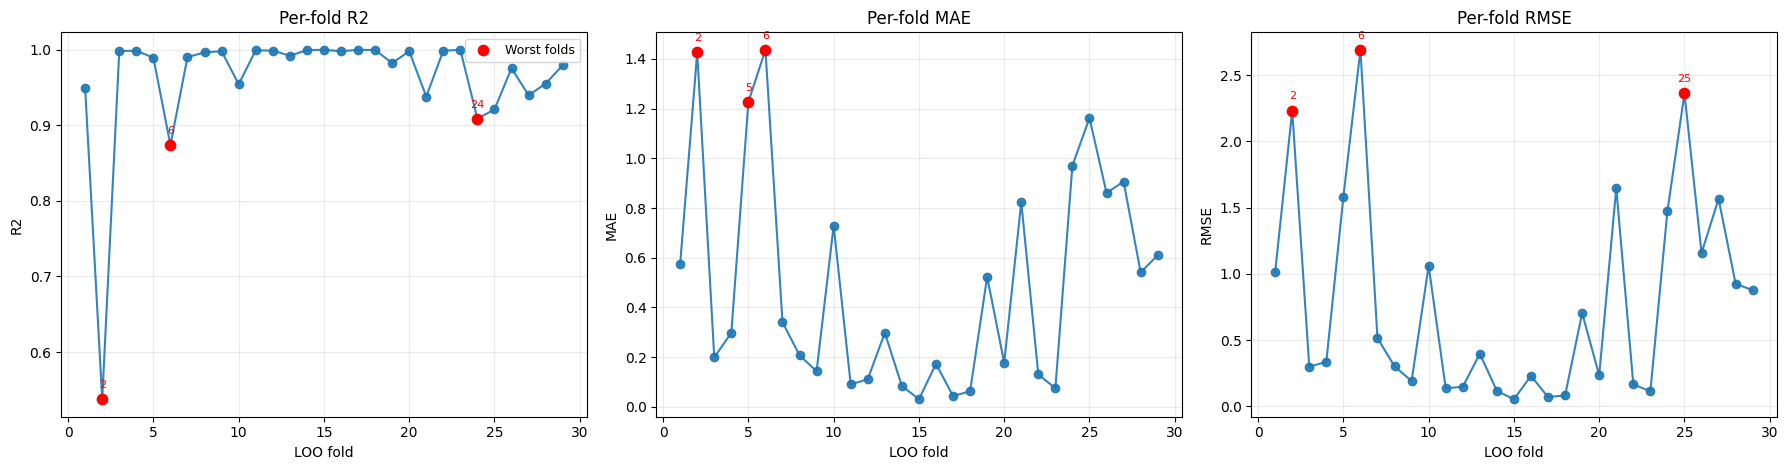


Constraint diagnostics (target magnitude vs front-MLP prediction)
   R_EX_glc__D_e_rev (sign=-1) | target med/mean=3.135200/3.880190 | pred med/mean=3.712226/4.027720
       R_EX_o2_e_rev (sign=-1) | target med/mean=7.953300/9.602582 | pred med/mean=8.797027/9.436375
      R_EX_co2_e_fwd (sign=+1) | target med/mean=7.557200/7.989682 | pred med/mean=7.363915/8.167814
         R_EX_etoh_e (sign=+1) | target med/mean=0.000000/0.011659 | pred med/mean=0.026199/0.035978
           R_EX_ac_e (sign=+1) | target med/mean=0.000000/0.083952 | pred med/mean=0.046148/0.051035


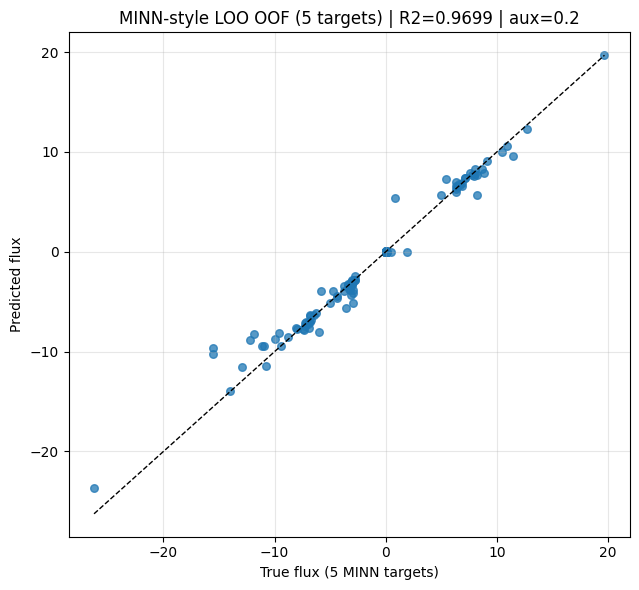

In [22]:
# Train exactly in MINN-repo manner: nested CV
# Outer loop: Leave-One-Out CV
# Inner loop: 5-fold CV hyperparameter search on training split only
# Model specifics here:
# - MLP predicts the same 5-channel reservoir context used by MINN
# - pFBA handoff keeps measured glucose/oxygen measured and adds predicted CO2/ethanol/acetate
# - full transformer input is reconstructed as predicted5 + fixed base_exchanges + zeros
#
# Aux-loss tuning:
# - Compare aux-loss weights [0.1, 0.3, 1.0]
# - Report pooled OOF metrics and per-target metrics for each weight
# - Keep downstream variables bound to the best aux weight by pooled OOF R2

from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.preprocessing import MinMaxScaler

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

set_seed(12345)

# MINN-style CV/HPO settings
minn_cv_seed = 12345
minn_cv_n_fold = 5
minn_cv_max_trials = 50
minn_cv_epochs = 100
minn_cv_batch_size = 5
minn_cv_early_stopping_patience = 20
minn_cv_early_stopping_min_delta = 1e-5

if device.type == "cuda" and minn_cv_batch_size > 2:
    print("CUDA detected: overriding batch_size 5 -> 2 to avoid OOM with full-output forward.")
    minn_cv_batch_size = 2

search_space = {
    "drop_rate": [0.1, 0.25, 0.5],
    "learning_rate": {"low": 2e-4, "high": 1e-3, "log": True},
    "weight_decay": {"low": 1e-6, "high": 1e-3, "log": True},
}

# Optuna objective = mean(inner-fold val loss) + lambda * std(inner-fold val loss)
# (stability-aware global tuning)
MINN_INNER_CV_STD_PENALTY = 0.25

# Training-stability settings
MINN_GRAD_CLIP_MAX_NORM = 1.0
MINN_LR_WARMUP_EPOCHS = max(3, min(10, minn_cv_epochs // 10))
MINN_LR_COSINE_MIN_FACTOR = 0.05

# IMPORTANT: run HPO once globally (not once per LOO split) to avoid extremely long runtimes.
MINN_HPO_ONCE = True

# Aux-loss tuning grid requested by user.
MINN_CONSTRAINT_AUX_WEIGHT_GRID = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Runtime guard:
# False -> run HPO once (anchor aux=1.0), reuse those hyperparameters for all aux weights.
# True  -> rerun HPO separately for each aux weight.
MINN_REDO_HPO_PER_AUX_WEIGHT = False

# Aux-weight selection criterion for downstream pipeline:
# - "pfba": choose aux by final FluxTransformer->pFBA metrics (Option 2).
# - "oof": choose aux by pooled OOF R2 on 5 supervised targets.
MINN_AUX_WEIGHT_SELECTION_MODE = "pfba"


def _make_model(drop_rate: float, device_obj):
    return FrozenFluxTransformerWithMLP(
        flux_transformer=model,
        input_dim=X_minn_np.shape[1],
        predicted_token_names=minn_target_token_names,
        fixed_base_token_values=fixed_base_token_values,
        hidden_dim=512,
        drop_rate=drop_rate,
    ).to(device_obj)


def _safe_r2(y_true_np, y_pred_np):
    y_true_np = np.asarray(y_true_np, dtype=np.float64)
    y_pred_np = np.asarray(y_pred_np, dtype=np.float64)
    if np.std(y_true_np) == 0 or np.std(y_pred_np) == 0:
        return 0.0
    return float(r2_score(y_true_np, y_pred_np))


def _train_eval_split(
    X_tr_np, y_tr_np, X_va_np, y_va_np,
    params, epochs, batch_size, device_obj,
    aux_weight,
    early_stopping_patience=minn_cv_early_stopping_patience,
    early_stopping_min_delta=minn_cv_early_stopping_min_delta,
):
    # MINN-repo-style preprocessing: fit scaler on train fold only, apply to train/val.
    x_scaler = MinMaxScaler()
    X_tr_np_scaled = x_scaler.fit_transform(X_tr_np)
    X_va_np_scaled = x_scaler.transform(X_va_np)

    model_local = _make_model(drop_rate=float(params["drop_rate"]), device_obj=device_obj)

    optimizer = torch.optim.AdamW(
        model_local.front_mlp.parameters(),
        lr=float(params["learning_rate"]),
        weight_decay=float(params["weight_decay"]),
    )
    criterion = nn.HuberLoss()

    use_amp = device_obj.type == "cuda"
    amp_device_type = "cuda" if use_amp else device_obj.type
    scaler = torch.amp.GradScaler(amp_device_type, enabled=use_amp)

    # Warmup + cosine decay LR schedule for stabler optimization on tiny folds.
    warmup_epochs = int(max(1, min(int(MINN_LR_WARMUP_EPOCHS), int(epochs))))

    def _lr_lambda(epoch_idx: int):
        if epoch_idx < warmup_epochs:
            return float(epoch_idx + 1) / float(warmup_epochs)

        progress_denom = max(1, int(epochs) - warmup_epochs)
        progress = float(epoch_idx - warmup_epochs) / float(progress_denom)
        progress = max(0.0, min(1.0, progress))

        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        min_factor = float(MINN_LR_COSINE_MIN_FACTOR)
        return min_factor + (1.0 - min_factor) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_lr_lambda)

    X_tr = torch.tensor(X_tr_np_scaled, dtype=torch.float32)
    y_tr = torch.tensor(y_tr_np, dtype=torch.float32)
    X_va = torch.tensor(X_va_np_scaled, dtype=torch.float32)
    y_va = torch.tensor(y_va_np, dtype=torch.float32)

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, y_tr),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_va, y_va),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )

    target_idx_t = minn_target_indices_t.to(device_obj)
    target_signs_t = minn_target_signs_t.to(device_obj)

    best_val_loss = float("inf")
    best_front_state = None
    no_improve_epochs = 0

    trained_epochs = 0

    for _epoch in range(epochs):
        trained_epochs = int(_epoch) + 1
        model_local.train()
        for xb, yb in train_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb = yb.to(device_obj, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                preds_all_layers, _sel = model_local(xb, output_subset=None)
                preds_last = preds_all_layers[:, :, -1]
                preds_target = preds_last.index_select(1, target_idx_t)

                # Front-MLP constraints are positive magnitudes; recover matching magnitude targets
                # from signed yb using source signs (*_rev columns had sign=-1 during mapping).
                pred_constraints = F.softplus(model_local.front_mlp(xb))
                constraint_targets = torch.clamp(yb * target_signs_t.unsqueeze(0), min=0.0)

                loss_flux = criterion(preds_target, yb)
                loss_constraints = criterion(pred_constraints, constraint_targets)
                loss = loss_flux + float(aux_weight) * loss_constraints

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model_local.front_mlp.parameters(),
                max_norm=float(MINN_GRAD_CLIP_MAX_NORM),
            )
            scaler.step(optimizer)
            scaler.update()

        # Epoch-level validation for early stopping
        model_local.eval()
        epoch_val_loss_sum = 0.0
        epoch_val_count = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device_obj, non_blocking=True)
                yb = yb.to(device_obj, non_blocking=True)

                with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                    preds_all_layers, _sel = model_local(xb, output_subset=None)
                    preds_last = preds_all_layers[:, :, -1]
                    preds_target = preds_last.index_select(1, target_idx_t)
                    pred_constraints = F.softplus(model_local.front_mlp(xb))
                    constraint_targets = torch.clamp(yb * target_signs_t.unsqueeze(0), min=0.0)

                    val_flux_loss = criterion(preds_target, yb)
                    val_constraint_loss = criterion(pred_constraints, constraint_targets)
                    val_loss = val_flux_loss + float(aux_weight) * val_constraint_loss

                bs = xb.size(0)
                epoch_val_loss_sum += float(val_loss.item()) * bs
                epoch_val_count += bs

        epoch_val_loss = epoch_val_loss_sum / max(epoch_val_count, 1)
        scheduler.step()

        if epoch_val_loss + float(early_stopping_min_delta) < best_val_loss:
            best_val_loss = epoch_val_loss
            best_front_state = {k: v.detach().cpu().clone() for k, v in model_local.front_mlp.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= int(early_stopping_patience):
                break

    if best_front_state is not None:
        model_local.front_mlp.load_state_dict(best_front_state)

    model_local.eval()
    val_loss_sum = 0.0
    val_count = 0
    preds_list = []
    true_list = []
    constraints_list = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb = yb.to(device_obj, non_blocking=True)

            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                preds_all_layers, _sel = model_local(xb, output_subset=None)
                preds_last = preds_all_layers[:, :, -1]
                preds_target = preds_last.index_select(1, target_idx_t)

                pred_constraints = F.softplus(model_local.front_mlp(xb))
                constraint_targets = torch.clamp(yb * target_signs_t.unsqueeze(0), min=0.0)

                val_flux_loss = criterion(preds_target, yb)
                val_constraint_loss = criterion(pred_constraints, constraint_targets)
                val_loss = val_flux_loss + float(aux_weight) * val_constraint_loss

            bs = xb.size(0)
            val_loss_sum += float(val_loss.item()) * bs
            val_count += bs

            preds_list.append(preds_target.detach().cpu().numpy())
            true_list.append(yb.detach().cpu().numpy())

            # Front-MLP predicted 5-channel reservoir context; pFBA uses only the added constraints.
            constraints_list.append(pred_constraints.detach().cpu().numpy())

    mean_val_loss = val_loss_sum / max(val_count, 1)
    y_pred = np.concatenate(preds_list, axis=0)
    y_true = np.concatenate(true_list, axis=0)
    y_constraints = np.concatenate(constraints_list, axis=0)

    if device_obj.type == "cuda":
        torch.cuda.empty_cache()

    return mean_val_loss, y_pred, y_true, y_constraints, trained_epochs


def _evaluate_params_inner_kfold(X_train_np, y_train_np, params, aux_weight, trial=None):
    kf = KFold(n_splits=minn_cv_n_fold, shuffle=True, random_state=minn_cv_seed)
    fold_losses = []

    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_train_np)):
        X_tr, y_tr = X_train_np[tr_idx], y_train_np[tr_idx]
        X_va, y_va = X_train_np[va_idx], y_train_np[va_idx]

        try:
            val_loss, _pred, _true, _c, _trained_epochs = _train_eval_split(
                X_tr, y_tr, X_va, y_va,
                params=params,
                epochs=minn_cv_epochs,
                batch_size=minn_cv_batch_size,
                device_obj=device,
                aux_weight=aux_weight,
            )
        except RuntimeError as e:
            if device.type == "cuda" and "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                val_loss, _pred, _true, _c, _trained_epochs = _train_eval_split(
                    X_tr, y_tr, X_va, y_va,
                    params=params,
                    epochs=minn_cv_epochs,
                    batch_size=1,
                    device_obj=torch.device("cpu"),
                    aux_weight=aux_weight,
                )
            else:
                raise

        fold_losses.append(float(val_loss))

        if trial is not None:
            running_mean = float(np.mean(fold_losses))
            running_std = float(np.std(fold_losses, ddof=1)) if len(fold_losses) > 1 else 0.0
            running_objective = running_mean + float(MINN_INNER_CV_STD_PENALTY) * running_std
            trial.report(float(running_objective), step=int(fold_idx))
            if trial.should_prune():
                raise optuna.TrialPruned()

    mean_loss = float(np.mean(fold_losses))
    std_loss = float(np.std(fold_losses, ddof=1)) if len(fold_losses) > 1 else 0.0
    objective = mean_loss + float(MINN_INNER_CV_STD_PENALTY) * std_loss
    return float(objective), mean_loss, std_loss, fold_losses


def _hpo_on_train_split(X_train_np, y_train_np, aux_weight):
    if OPTUNA_AVAILABLE:
        def objective(trial):
            params = {
                "drop_rate": trial.suggest_categorical("drop_rate", search_space["drop_rate"]),
                "learning_rate": trial.suggest_float(
                    "learning_rate",
                    float(search_space["learning_rate"]["low"]),
                    float(search_space["learning_rate"]["high"]),
                    log=bool(search_space["learning_rate"]["log"]),
                ),
                "weight_decay": trial.suggest_float(
                    "weight_decay",
                    float(search_space["weight_decay"]["low"]),
                    float(search_space["weight_decay"]["high"]),
                    log=bool(search_space["weight_decay"]["log"]),
                ),
            }
            objective_value, mean_loss, std_loss, _fold_losses = _evaluate_params_inner_kfold(
                X_train_np,
                y_train_np,
                params,
                aux_weight=aux_weight,
                trial=trial,
            )
            trial.set_user_attr("mean_val_loss", float(mean_loss))
            trial.set_user_attr("std_val_loss", float(std_loss))
            return float(objective_value)

        sampler = optuna.samplers.TPESampler(seed=minn_cv_seed, multivariate=True, group=True)
        pruner = optuna.pruners.MedianPruner(
            n_startup_trials=max(5, minn_cv_n_fold),
            n_warmup_steps=1,
            interval_steps=1,
        )
        study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
        study.optimize(objective, n_trials=minn_cv_max_trials, n_jobs=1)

        trial_rows = []
        for t in study.trials:
            if t.value is None:
                continue
            trial_rows.append({
                "trial": int(t.number),
                "value": float(t.value),
                "mean_val_loss": float(t.user_attrs.get("mean_val_loss", np.nan)),
                "std_val_loss": float(t.user_attrs.get("std_val_loss", np.nan)),
                "aux_weight": float(aux_weight),
                "drop_rate": t.params.get("drop_rate", np.nan),
                "learning_rate": t.params.get("learning_rate", np.nan),
                "weight_decay": t.params.get("weight_decay", np.nan),
                "state": str(t.state),
            })
        trials_df = pd.DataFrame(trial_rows).sort_values("value", ascending=True).reset_index(drop=True)
        best_params = study.best_params
        best_value = float(study.best_value)
        attempted_trials = int(len(study.trials))
        completed_trials = int(len([t for t in study.trials if t.value is not None]))
        print(f"HPO completed for aux_weight={float(aux_weight)}: {attempted_trials}/{minn_cv_max_trials} trials attempted ({completed_trials} completed)")
        print(f"Best hyperparameters after trials: {best_params}")
        print(f"Best inner_cv_objective after trials: {best_value:.6f}")
        return best_params, best_value, trials_df

    best_params = None
    best_score = float("inf")
    grid_rows = []
    # Coarse deterministic fallback grid that samples log-space ranges used in Optuna mode.
    lr_grid = [2e-4, 3e-4, 5e-4, 7e-4, 1e-3]
    wd_grid = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
    for dr in search_space["drop_rate"]:
        for lr in lr_grid:
            for wd in wd_grid:
                params = {"drop_rate": dr, "learning_rate": float(lr), "weight_decay": float(wd)}
                score, mean_loss, std_loss, _fold_losses = _evaluate_params_inner_kfold(
                    X_train_np,
                    y_train_np,
                    params,
                    aux_weight=aux_weight,
                    trial=None,
                )
                grid_rows.append({
                    "trial": len(grid_rows),
                    "value": float(score),
                    "mean_val_loss": float(mean_loss),
                    "std_val_loss": float(std_loss),
                    "aux_weight": float(aux_weight),
                    "drop_rate": dr,
                    "learning_rate": float(lr),
                    "weight_decay": float(wd),
                    "state": "COMPLETE",
                })
                if score < best_score:
                    best_score = score
                    best_params = params
    trials_df = pd.DataFrame(grid_rows).sort_values("value", ascending=True).reset_index(drop=True)
    print(f"Grid HPO completed for aux_weight={float(aux_weight)}: {len(grid_rows)} combinations")
    print(f"Best hyperparameters after trials: {best_params}")
    print(f"Best inner_cv_objective after trials: {float(best_score):.6f}")
    return best_params, float(best_score), trials_df


def _run_nested_loo_for_aux(aux_weight, best_params_global=None, best_inner_loss_global=None):
    loo = LeaveOneOut()

    R2_loo = []
    MAE_loo = []
    RMSE_loo = []
    NE_loo = []
    best_params_per_split = []
    loo_val_loss_rows = []
    epochs_trained_loo = []

    total_run = X_minn_np.shape[0]
    count = 1

    oof_true_local = np.zeros_like(y_minn_np, dtype=np.float32)
    oof_pred_local = np.zeros_like(y_minn_np, dtype=np.float32)
    oof_pred_constraints_local = np.zeros_like(y_minn_np, dtype=np.float32)

    print("=" * 80)
    print(f"MINN-style nested CV training started | aux_weight={aux_weight}")
    print(f"Outer LOO runs: {total_run}")
    print(f"Inner KFold: {minn_cv_n_fold}, trials: {minn_cv_max_trials}, epochs: {minn_cv_epochs}, batch: {minn_cv_batch_size}")
    print(f"Stability objective: mean + {MINN_INNER_CV_STD_PENALTY} * std")
    print(f"Grad clip max norm: {MINN_GRAD_CLIP_MAX_NORM} | warmup epochs: {MINN_LR_WARMUP_EPOCHS} | cosine min factor: {MINN_LR_COSINE_MIN_FACTOR}")
    print(f"Early stopping: patience={minn_cv_early_stopping_patience}, min_delta={minn_cv_early_stopping_min_delta}")
    print(f"Reservoir context predicted by front MLP: {MINN_RESERVOIR_CONTEXT_SOURCE}")
    print(f"pFBA extra constraints extracted from OOF predictions: {MINN_LEARNED_CONSTRAINT_SOURCE}")
    print(f"Optuna available: {OPTUNA_AVAILABLE}")

    if MINN_HPO_ONCE and best_params_global is not None:
        print(f"Using provided global best_params: {best_params_global}")
        print(f"Provided global inner_cv_loss: {float(best_inner_loss_global):.6f}")

    for train_idx, val_idx in loo.split(X_minn_np):
        X_train_np = X_minn_np[train_idx]
        y_train_np = y_minn_np[train_idx]
        X_val_np = X_minn_np[val_idx]
        y_val_np = y_minn_np[val_idx]

        if MINN_HPO_ONCE:
            if best_params_global is None:
                best_params, best_inner_loss, _trials_df = _hpo_on_train_split(X_train_np, y_train_np, aux_weight=aux_weight)
            else:
                best_params, best_inner_loss = best_params_global, best_inner_loss_global
        else:
            best_params, best_inner_loss, _trials_df = _hpo_on_train_split(X_train_np, y_train_np, aux_weight=aux_weight)

        best_params_per_split.append(best_params)

        try:
            _val_loss, y_pred_val, y_true_val, y_pred_constraints_val, _epochs_trained = _train_eval_split(
                X_train_np, y_train_np, X_val_np, y_val_np,
                params=best_params,
                epochs=minn_cv_epochs,
                batch_size=minn_cv_batch_size,
                device_obj=device,
                aux_weight=aux_weight,
            )
        except RuntimeError as e:
            if device.type == "cuda" and "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                _val_loss, y_pred_val, y_true_val, y_pred_constraints_val, _epochs_trained = _train_eval_split(
                    X_train_np, y_train_np, X_val_np, y_val_np,
                    params=best_params,
                    epochs=minn_cv_epochs,
                    batch_size=1,
                    device_obj=torch.device("cpu"),
                    aux_weight=aux_weight,
                )
            else:
                raise

        i = int(val_idx[0])
        left_out_experiment = minn_experiments[i] if i < len(minn_experiments) else f"idx_{i}"
        left_out_flux_str = ", ".join(
            [f"{src}={float(y_true_val[0, j]):.6f}" for j, (src, _tok, _idx, _sign) in enumerate(minn_mapped_sources)]
        )
        oof_true_local[i] = y_true_val[0]
        oof_pred_local[i] = y_pred_val[0]
        oof_pred_constraints_local[i] = y_pred_constraints_val[0]

        R2_value = _safe_r2(y_true_val.flatten(), y_pred_val.flatten())
        mae_value = float(np.mean(np.abs(y_true_val - y_pred_val)))
        rmse_value = float(np.sqrt(np.mean((y_true_val - y_pred_val) ** 2)))
        ne_value = float(np.nan_to_num(np.linalg.norm(y_true_val - y_pred_val) / np.linalg.norm(y_true_val), posinf=0, neginf=0, nan=0))

        R2_loo.append(R2_value)
        MAE_loo.append(mae_value)
        RMSE_loo.append(rmse_value)
        NE_loo.append(ne_value)
        epochs_trained_loo.append(int(_epochs_trained))
        loo_val_loss_rows.append({
            "epochs_trained": int(_epochs_trained),
            "aux_weight": float(aux_weight),
            "loo_run": int(count),
            "sample_idx": int(i),
            "val_loss": float(_val_loss),
            "R2": float(R2_value),
            "MAE": float(mae_value),
            "RMSE": float(rmse_value),
            "NE": float(ne_value),
        })

        print(f"run {count}/{total_run}")
        print(f"  left_out_experiment: {left_out_experiment}")
        print(f"  left_out_target_fluxes(signed): {left_out_flux_str}")
        print(f"  best_params: {best_params}")
        print(f"  inner_cv_objective: {float(best_inner_loss):.6f}")
        print(f"  epochs_trained: {_epochs_trained}/{minn_cv_epochs}")
        print(f"  R2: {R2_value:.6f} | MAE: {mae_value:.6f} | RMSE: {rmse_value:.6f} | NE: {ne_value:.6f}")

        count += 1

    r2_oof = _safe_r2(oof_true_local.ravel(), oof_pred_local.ravel())
    mae_oof = mean_absolute_error(oof_true_local.ravel(), oof_pred_local.ravel())
    rmse_oof = root_mean_squared_error(oof_true_local.ravel(), oof_pred_local.ravel())
    ne_oof = float(np.nan_to_num(np.linalg.norm(oof_true_local.ravel() - oof_pred_local.ravel()) / np.linalg.norm(oof_true_local.ravel()), posinf=0, neginf=0, nan=0))

    per_target_rows = []
    for j, (src, tok, idx, sign) in enumerate(minn_mapped_sources):
        yt = oof_true_local[:, j]
        yp = oof_pred_local[:, j]
        per_target_rows.append({
            "aux_weight": float(aux_weight),
            "source_flux": src,
            "mapped_token": tok,
            "target_index": int(idx),
            "sign": float(sign),
            "R2": _safe_r2(yt, yp),
            "MAE": float(np.mean(np.abs(yt - yp))),
            "RMSE": float(np.sqrt(np.mean((yt - yp) ** 2))),
            "NE": float(np.nan_to_num(np.linalg.norm(yt - yp) / np.linalg.norm(yt), posinf=0, neginf=0, nan=0)),
        })
    per_target_df = pd.DataFrame(per_target_rows)

    loo_val_loss_df_local = pd.DataFrame(loo_val_loss_rows)

    print(f"=== MINN-style nested CV summary | aux_weight={aux_weight} ===")
    print(f"LOO mean R2:   {np.mean(R2_loo):.6f} +/- {np.std(R2_loo, ddof=1):.6f}")
    print(f"LOO mean MAE:  {np.mean(MAE_loo):.6f} +/- {np.std(MAE_loo, ddof=1):.6f}")
    print(f"LOO mean RMSE: {np.mean(RMSE_loo):.6f} +/- {np.std(RMSE_loo, ddof=1):.6f}")
    print(f"LOO mean NE:   {np.mean(NE_loo):.6f} +/- {np.std(NE_loo, ddof=1):.6f}")
    print(f"Pooled OOF R2:   {r2_oof:.6f}")
    print(f"Pooled OOF MAE:  {mae_oof:.6f}")
    print(f"Pooled OOF RMSE: {rmse_oof:.6f}")
    print(f"Pooled OOF NE:   {ne_oof:.6f}")
    if len(epochs_trained_loo) > 0:
        print(f"Epochs trained per LOO: mean={float(np.mean(epochs_trained_loo)):.2f}, min={int(np.min(epochs_trained_loo))}, max={int(np.max(epochs_trained_loo))}")

    return {
        "aux_weight": float(aux_weight),
        "R2_loo": R2_loo,
        "MAE_loo": MAE_loo,
        "RMSE_loo": RMSE_loo,
        "NE_loo": NE_loo,
        "best_params_per_split": best_params_per_split,
        "loo_val_loss_df": loo_val_loss_df_local,
        "epochs_trained_loo": epochs_trained_loo,
        "oof_true": oof_true_local,
        "oof_pred": oof_pred_local,
        "oof_pred_constraints": oof_pred_constraints_local,
        "pooled_R2": float(r2_oof),
        "pooled_MAE": float(mae_oof),
        "pooled_RMSE": float(rmse_oof),
        "pooled_NE": float(ne_oof),
        "loo_mean_R2": float(np.mean(R2_loo)),
        "loo_std_R2": float(np.std(R2_loo, ddof=1)),
        "loo_mean_MAE": float(np.mean(MAE_loo)),
        "loo_std_MAE": float(np.std(MAE_loo, ddof=1)),
        "loo_mean_RMSE": float(np.mean(RMSE_loo)),
        "loo_std_RMSE": float(np.std(RMSE_loo, ddof=1)),
        "loo_mean_NE": float(np.mean(NE_loo)),
        "loo_std_NE": float(np.std(NE_loo, ddof=1)),
        "per_target_df": per_target_df,
    }


print("Aux-loss sweep configuration")
print(f"  weights: {MINN_CONSTRAINT_AUX_WEIGHT_GRID}")
print(f"  HPO once: {MINN_HPO_ONCE}")
print(f"  redo HPO per aux weight: {MINN_REDO_HPO_PER_AUX_WEIGHT}")

results_by_aux = {}
optuna_trials_by_aux = {}

if MINN_HPO_ONCE and not MINN_REDO_HPO_PER_AUX_WEIGHT:
    # Keep runtime bounded: one HPO on anchor aux=1.0, reuse params for all weights.
    hpo_anchor_weight = 1.0 if 1.0 in MINN_CONSTRAINT_AUX_WEIGHT_GRID else float(MINN_CONSTRAINT_AUX_WEIGHT_GRID[-1])
    print("Running one-time global HPO on full dataset...")
    best_params_global, best_inner_loss_global, trials_df_global = _hpo_on_train_split(
        X_minn_np,
        y_minn_np,
        aux_weight=hpo_anchor_weight,
    )
    print(f"Global best_params (anchor aux={hpo_anchor_weight}): {best_params_global}")
    print(f"Global inner_cv_objective: {best_inner_loss_global:.6f}")
    optuna_trials_by_aux[float(hpo_anchor_weight)] = trials_df_global

    for aw in MINN_CONSTRAINT_AUX_WEIGHT_GRID:
        awf = float(aw)
        results_by_aux[awf] = _run_nested_loo_for_aux(
            aux_weight=awf,
            best_params_global=best_params_global,
            best_inner_loss_global=best_inner_loss_global,
        )
else:
    # Full tuning path: each aux weight can have its own HPO.
    for aw in MINN_CONSTRAINT_AUX_WEIGHT_GRID:
        awf = float(aw)
        print("Running global HPO on full dataset for aux_weight=", awf)
        best_params_aw, best_inner_loss_aw, trials_df_aw = _hpo_on_train_split(
            X_minn_np,
            y_minn_np,
            aux_weight=awf,
        )
        optuna_trials_by_aux[awf] = trials_df_aw
        print(f"Global best_params (aux={awf}): {best_params_aw}")
        print(f"Global inner_cv_objective: {best_inner_loss_aw:.6f}")

        results_by_aux[awf] = _run_nested_loo_for_aux(
            aux_weight=awf,
            best_params_global=best_params_aw if MINN_HPO_ONCE else None,
            best_inner_loss_global=best_inner_loss_aw if MINN_HPO_ONCE else None,
        )

# Build pooled comparison table
pooled_rows = []
for awf, res in results_by_aux.items():
    pooled_rows.append({
        "aux_weight": float(awf),
        "pooled_R2": float(res["pooled_R2"]),
        "pooled_MAE": float(res["pooled_MAE"]),
        "pooled_RMSE": float(res["pooled_RMSE"]),
        "pooled_NE": float(res["pooled_NE"]),
        "loo_mean_R2": float(res["loo_mean_R2"]),
        "loo_std_R2": float(res["loo_std_R2"]),
        "loo_mean_MAE": float(res["loo_mean_MAE"]),
        "loo_std_MAE": float(res["loo_std_MAE"]),
        "loo_mean_RMSE": float(res["loo_mean_RMSE"]),
        "loo_std_RMSE": float(res["loo_std_RMSE"]),
        "loo_mean_NE": float(res["loo_mean_NE"]),
        "loo_std_NE": float(res["loo_std_NE"]),
    })
minn_aux_weight_pooled_df = pd.DataFrame(pooled_rows).sort_values("pooled_R2", ascending=False).reset_index(drop=True)

# Build per-target comparison table
minn_aux_weight_per_target_df = pd.concat(
    [res["per_target_df"] for res in results_by_aux.values()],
    axis=0,
    ignore_index=True,
)

print("\n=== Aux-weight comparison: pooled OOF metrics ===")
display(minn_aux_weight_pooled_df)

print("\n=== Aux-weight comparison: per-target metrics ===")
display(minn_aux_weight_per_target_df.sort_values(["source_flux", "aux_weight"]).reset_index(drop=True))

def _evaluate_fluxtransformer_to_pfba_from_oof_constraints(oof_constraints_np):
    from pathlib import Path

    tr_df = pd.read_csv(Path(MINN_DATA_DIR) / "transcriptomics.csv")
    pr_df = pd.read_csv(Path(MINN_DATA_DIR) / "proteomics.csv")
    fl_df = pd.read_csv(Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE)

    x_df_tmp = tr_df.merge(pr_df, on="experiment", how="left")
    x_df_tmp = x_df_tmp.merge(fl_df[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
    x_df_tmp = x_df_tmp[x_df_tmp["experiment"].isin(fl_df["experiment"])].reset_index(drop=True)
    exp_order_oof = x_df_tmp["experiment"].tolist()

    if len(exp_order_oof) != oof_constraints_np.shape[0]:
        raise RuntimeError(
            f"Experiment/OOF length mismatch: {len(exp_order_oof)} vs {oof_constraints_np.shape[0]}."
        )
    if oof_constraints_np.shape[1] != len(MINN_RESERVOIR_CONTEXT_SOURCE):
        raise RuntimeError(
            f"Expected {len(MINN_RESERVOIR_CONTEXT_SOURCE)} reservoir-context predictions in oof_pred_constraints, "
            f"got {oof_constraints_np.shape[1]}. Re-run the MINN training cell after updating the reservoir setup."
        )

    src_to_idx = {s: i for i, s in enumerate(MINN_RESERVOIR_CONTEXT_SOURCE)}
    for s in MINN_LEARNED_CONSTRAINT_SOURCE:
        if s not in src_to_idx:
            raise ValueError(f"Missing expected learned source in MINN_RESERVOIR_CONTEXT_SOURCE: {s}")

    pred_vin_local_df = pd.DataFrame({
        "experiment": exp_order_oof,
        "R_EX_co2_e_fwd_pred": np.maximum(0.0, oof_constraints_np[:, src_to_idx["R_EX_co2_e_fwd"]]),
        "R_EX_etoh_e_pred": np.maximum(0.0, oof_constraints_np[:, src_to_idx["R_EX_etoh_e"]]),
        "R_EX_ac_e_pred": np.maximum(0.0, oof_constraints_np[:, src_to_idx["R_EX_ac_e"]]),
    })

    flux_df_eval_local = fl_df.merge(pred_vin_local_df, on="experiment", how="inner")
    if flux_df_eval_local.empty:
        raise RuntimeError("Empty merged dataframe for FluxTransformer to pFBA evaluation.")

    if "mapped_metrics" in globals() and mapped_metrics:
        mapped_metrics_local = mapped_metrics
    else:
        if "_minn_to_flux_token" not in globals():
            raise RuntimeError("_minn_to_flux_token not found. Run baseline mapping cell before pFBA-based aux selection.")
        metric_source_cols_local = [c for c in fl_df.columns if c != "experiment"]
        mapped_metrics_local = []
        for src_m in metric_source_cols_local:
            tok, sign = _minn_to_flux_token(src_m, outputs)
            if tok is not None:
                mapped_metrics_local.append((src_m, tok, float(sign)))

    if not mapped_metrics_local:
        raise RuntimeError("No mapped metrics available for FluxTransformer to pFBA evaluation.")

    def _metric_row_local(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=np.float64)
        y_pred = np.asarray(y_pred, dtype=np.float64)
        if np.std(y_true) == 0 or np.std(y_pred) == 0:
            R2 = 0.0
        else:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            R2 = 0.0 if np.isnan(r) else float(r * r)
        mae = float(np.mean(np.abs(y_true - y_pred)))
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
        return R2, mae, rmse, ne

    pred_rows_local = []
    metric_rows_local = []
    failed_samples_local = []

    for _, row in flux_df_eval_local.iterrows():
        exp_name = row["experiment"]

        glc_uptake_meas = float(row["R_EX_glc__D_e_rev"])
        o2_uptake_meas = float(row["R_EX_o2_e_rev"])
        co2_pred = float(row["R_EX_co2_e_fwd_pred"])
        etoh_pred = float(row["R_EX_etoh_e_pred"])
        ac_pred = float(row["R_EX_ac_e_pred"])

        m = base_cobra_model.copy()
        try:
            m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake_meas
            m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake_meas

            co2_rxn = m.reactions.get_by_id("EX_co2_e")
            co2_rxn.lower_bound = 0.0
            co2_rxn.upper_bound = co2_pred

            etoh_rxn = m.reactions.get_by_id("EX_etoh_e")
            etoh_rxn.lower_bound = 0.0
            etoh_rxn.upper_bound = etoh_pred

            ac_rxn = m.reactions.get_by_id("EX_ac_e")
            ac_rxn.lower_bound = 0.0
            ac_rxn.upper_bound = ac_pred
        except KeyError as e:
            raise KeyError("Expected EX_glc__D_e, EX_o2_e, EX_co2_e, EX_etoh_e, EX_ac_e in iML1515 model.") from e

        try:
            sol = cobra_pfba(m)
            sol_status = getattr(sol, "status", "optimal")
            if sol_status != "optimal":
                raise RuntimeError(f"pFBA status={sol_status}")
        except Exception as e:
            failed_samples_local.append((exp_name, str(e)))
            continue

        y_true = []
        y_pred = []
        pred_row = {"experiment": exp_name}
        for src_m, tok_m, sign_m in mapped_metrics_local:
            rxn_id = tok_m[:-5] if tok_m.endswith("_flux") else tok_m
            pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign_m
            true_val = float(row[src_m])
            y_true.append(true_val)
            y_pred.append(pred_val)
            pred_row[src_m] = pred_val

        R2, mae, rmse, ne = _metric_row_local(y_true, y_pred)
        metric_rows_local.append({
            "experiment": exp_name,
            "R2": R2,
            "MAE": mae,
            "RMSE": rmse,
            "NE": ne,
        })
        pred_rows_local.append(pred_row)

    metrics_df_local = pd.DataFrame(metric_rows_local)
    pred_df_local = pd.DataFrame(pred_rows_local)

    if metrics_df_local.empty:
        summary_df_local = pd.DataFrame(columns=["avg", "std"], index=["R2", "MAE", "RMSE", "NE"])
    else:
        summary_df_local = pd.DataFrame({
            "avg": [
                float(metrics_df_local["R2"].mean()),
                float(metrics_df_local["MAE"].mean()),
                float(metrics_df_local["RMSE"].mean()),
                float(metrics_df_local["NE"].mean()),
            ],
            "std": [
                float(metrics_df_local["R2"].std(ddof=0)),
                float(metrics_df_local["MAE"].std(ddof=0)),
                float(metrics_df_local["RMSE"].std(ddof=0)),
                float(metrics_df_local["NE"].std(ddof=0)),
            ],
        }, index=["R2", "MAE", "RMSE", "NE"])

    return {
        "summary_df": summary_df_local,
        "metrics_per_sample_df": metrics_df_local,
        "pred_df": pred_df_local,
        "pred_vin_df": pred_vin_local_df,
        "failed_samples": failed_samples_local,
        "n_total": int(len(flux_df_eval_local)),
        "n_eval": int(len(metrics_df_local)),
    }


minn_aux_weight_selection_mode = str(MINN_AUX_WEIGHT_SELECTION_MODE).lower().strip()
minn_aux_weight_pfba_df = pd.DataFrame()
minn_aux_weight_pfba_by_aux = {}

if minn_aux_weight_selection_mode == "pfba":
    required_pfba_globals = ["base_cobra_model", "cobra_pfba", "outputs", "MINN_RESERVOIR_CONTEXT_SOURCE", "MINN_LEARNED_CONSTRAINT_SOURCE"]
    missing_pfba_globals = [g for g in required_pfba_globals if g not in globals()]

    if missing_pfba_globals:
        print("Warning: missing globals for pFBA-based aux selection:", missing_pfba_globals)
        print("Falling back to OOF-based aux selection.")
        minn_aux_weight_selection_mode = "oof"
    else:
        pfba_rows = []
        for awf, res in results_by_aux.items():
            pfba_res = _evaluate_fluxtransformer_to_pfba_from_oof_constraints(res["oof_pred_constraints"])
            minn_aux_weight_pfba_by_aux[float(awf)] = pfba_res

            if pfba_res["summary_df"].empty:
                pfba_rows.append({
                    "aux_weight": float(awf),
                    "n_eval": int(pfba_res["n_eval"]),
                    "n_total": int(pfba_res["n_total"]),
                    "pfba_R2_avg": np.nan,
                    "pfba_R2_std": np.nan,
                    "pfba_MAE_avg": np.nan,
                    "pfba_MAE_std": np.nan,
                    "pfba_RMSE_avg": np.nan,
                    "pfba_RMSE_std": np.nan,
                    "pfba_NE_avg": np.nan,
                    "pfba_NE_std": np.nan,
                })
            else:
                s = pfba_res["summary_df"]
                pfba_rows.append({
                    "aux_weight": float(awf),
                    "n_eval": int(pfba_res["n_eval"]),
                    "n_total": int(pfba_res["n_total"]),
                    "pfba_R2_avg": float(s.loc["R2", "avg"]),
                    "pfba_R2_std": float(s.loc["R2", "std"]),
                    "pfba_MAE_avg": float(s.loc["MAE", "avg"]),
                    "pfba_MAE_std": float(s.loc["MAE", "std"]),
                    "pfba_RMSE_avg": float(s.loc["RMSE", "avg"]),
                    "pfba_RMSE_std": float(s.loc["RMSE", "std"]),
                    "pfba_NE_avg": float(s.loc["NE", "avg"]),
                    "pfba_NE_std": float(s.loc["NE", "std"]),
                })

        minn_aux_weight_pfba_df = pd.DataFrame(pfba_rows)
        print("\n=== Aux-weight comparison: final FluxTransformer->pFBA metrics ===")
        display(minn_aux_weight_pfba_df.sort_values(["pfba_R2_avg", "pfba_MAE_avg", "pfba_RMSE_avg", "pfba_NE_avg"], ascending=[False, True, True, True]).reset_index(drop=True))

# Select best aux and expose canonical variables for downstream cells.
if minn_aux_weight_selection_mode == "pfba" and not minn_aux_weight_pfba_df.empty:
    feasible_pfba = minn_aux_weight_pfba_df.dropna(subset=["pfba_R2_avg"]).copy()
    if feasible_pfba.empty:
        print("Warning: no feasible pFBA rows across aux weights; falling back to OOF-based selection.")
        best_aux_weight = float(minn_aux_weight_pooled_df.iloc[0]["aux_weight"])
    else:
        feasible_pfba = feasible_pfba.sort_values(
            ["pfba_R2_avg", "pfba_MAE_avg", "pfba_RMSE_avg", "pfba_NE_avg"],
            ascending=[False, True, True, True],
        ).reset_index(drop=True)
        best_aux_weight = float(feasible_pfba.iloc[0]["aux_weight"])
        print(f"Selected by pFBA metrics -> aux_weight={best_aux_weight}")
else:
    best_aux_weight = float(minn_aux_weight_pooled_df.iloc[0]["aux_weight"])
    print(f"Selected by OOF metrics -> aux_weight={best_aux_weight}")

best_res = results_by_aux[best_aux_weight]
MINN_CONSTRAINT_AUX_WEIGHT = best_aux_weight

R2_loo = best_res["R2_loo"]
MAE_loo = best_res["MAE_loo"]
RMSE_loo = best_res["RMSE_loo"]
NE_loo = best_res["NE_loo"]
best_params_per_split = best_res["best_params_per_split"]
loo_val_loss_df = best_res["loo_val_loss_df"]

oof_true = best_res["oof_true"]
oof_pred = best_res["oof_pred"]
oof_pred_constraints = best_res["oof_pred_constraints"]

r2_oof = float(best_res["pooled_R2"])
mae_oof = float(best_res["pooled_MAE"])
rmse_oof = float(best_res["pooled_RMSE"])

# Optuna trials table for the selected aux-weight run.
last_optuna_trials_df = optuna_trials_by_aux.get(best_aux_weight, pd.DataFrame())

print("\nSelected aux weight for downstream cells:", MINN_CONSTRAINT_AUX_WEIGHT, "| mode=", minn_aux_weight_selection_mode)
print("=== MINN-style nested CV summary (selected) ===")
print(f"LOO mean R2:   {np.mean(R2_loo):.6f} +/- {np.std(R2_loo, ddof=1):.6f}")
print(f"LOO mean MAE:  {np.mean(MAE_loo):.6f} +/- {np.std(MAE_loo, ddof=1):.6f}")
print(f"LOO mean RMSE: {np.mean(RMSE_loo):.6f} +/- {np.std(RMSE_loo, ddof=1):.6f}")
print(f"LOO mean NE:   {np.mean(NE_loo):.6f} +/- {np.std(NE_loo, ddof=1):.6f}")
print(f"Pooled OOF R2:   {r2_oof:.6f}")
print(f"Pooled OOF MAE:  {mae_oof:.6f}")
print(f"Pooled OOF RMSE: {rmse_oof:.6f}")

print("\nPer-LOO validation loss table (selected aux weight)")
display(loo_val_loss_df)

# Visual diagnostics: per-fold R2/MAE/RMSE (selected aux weight)
if isinstance(loo_val_loss_df, pd.DataFrame) and not loo_val_loss_df.empty:
    fold_x = loo_val_loss_df["loo_run"].astype(int).values

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
    metric_specs = [
        ("R2", False),   # lower is worse
        ("MAE", True),   # higher is worse
        ("RMSE", True),  # higher is worse
    ]

    for ax, (metric_name, higher_is_worse) in zip(axes, metric_specs):
        y = loo_val_loss_df[metric_name].astype(float).values
        ax.plot(fold_x, y, marker="o", lw=1.5, color="#1f77b4", alpha=0.9)

        # Highlight the 3 worst folds for each metric
        k = min(3, len(y))
        if higher_is_worse:
            worst_idx = np.argsort(-y)[:k]
        else:
            worst_idx = np.argsort(y)[:k]

        ax.scatter(fold_x[worst_idx], y[worst_idx], color="red", s=55, zorder=5, label="Worst folds")

        for wi in worst_idx:
            ax.annotate(
                str(int(fold_x[wi])),
                (fold_x[wi], y[wi]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
                color="red",
            )

        ax.set_title(f"Per-fold {metric_name}")
        ax.set_xlabel("LOO fold")
        ax.set_ylabel(metric_name)
        ax.grid(alpha=0.25)

    axes[0].legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

if isinstance(last_optuna_trials_df, pd.DataFrame) and not last_optuna_trials_df.empty:
    print("\nCompact HPO trials (top 10 by inner-CV loss) for selected/anchor aux weight")
    display(last_optuna_trials_df.head(10))
    if "state" in last_optuna_trials_df.columns:
        print("Pruning/state counts:")
        print(last_optuna_trials_df["state"].value_counts(dropna=False))

# Diagnostic prints for split->unsplit sign handling and front-MLP constraint quality.
target_magnitudes = np.maximum(0.0, oof_true * minn_target_signs.reshape(1, -1))
pred_magnitudes = np.maximum(0.0, oof_pred_constraints)
print("\nConstraint diagnostics (target magnitude vs front-MLP prediction)")
for j, (src, tok, idx, sign) in enumerate(minn_mapped_sources):
    t_med = float(np.median(target_magnitudes[:, j]))
    p_med = float(np.median(pred_magnitudes[:, j]))
    t_mean = float(np.mean(target_magnitudes[:, j]))
    p_mean = float(np.mean(pred_magnitudes[:, j]))
    print(
        f"  {src:>18} (sign={sign:+.0f}) | "
        f"target med/mean={t_med:.6f}/{t_mean:.6f} | "
        f"pred med/mean={p_med:.6f}/{p_mean:.6f}"
    )

plt.figure(figsize=(6.5, 6.0))
plt.scatter(oof_true.ravel(), oof_pred.ravel(), alpha=0.75, s=30)
xy_min = float(min(oof_true.min(), oof_pred.min()))
xy_max = float(max(oof_true.max(), oof_pred.max()))
plt.plot([xy_min, xy_max], [xy_min, xy_max], 'k--', lw=1)
plt.xlabel("True flux (5 MINN targets)")
plt.ylabel("Predicted flux")
plt.title(f"MINN-style LOO OOF (5 targets) | R2={r2_oof:.4f} | aux={MINN_CONSTRAINT_AUX_WEIGHT}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Baseline pFBA

This cell computes the baseline row for the MINN article Table 4-style comparison adapted to FluxTransformer. It runs pFBA on the unsplit, unpruned iML1515 model using only the measured medium inputs available for every sample: glucose uptake (`R_EX_glc__D_e_rev`) and oxygen uptake (`R_EX_o2_e_rev`).

No reservoir-predicted constraints are added here. The resulting metrics are the reference point for the next FluxTransformer + pFBA cell, where predicted CO2, ethanol, and acetate constraints are added.

Metrics are computed per sample across the mapped measured fluxes, then summarized as mean and standard deviation across samples: R2, MAE, RMSE, and NE.


In [23]:
# Baseline pFBA (paper-style metrics), without FluxTransformer to pFBA
# Uses ONLY measured glucose and oxygen uptake as inputs.

from pathlib import Path

try:
    from cobra.io import read_sbml_model
    from cobra.flux_analysis import pfba as cobra_pfba
except Exception as e:
    raise ImportError(
        "cobra is required for pFBA baseline evaluation. Install cobra in the notebook environment."
    ) from e

fluxomics_path = Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE
if not fluxomics_path.exists():
    raise FileNotFoundError(f"Fluxomics file not found: {fluxomics_path}")

flux_df = pd.read_csv(fluxomics_path)

# Paper-style evaluation flux set: all measured fluxomics columns (exclude experiment id).
metric_source_cols = [c for c in flux_df.columns if c != "experiment"]

# Map MINN split-naming columns into iML1515 FluxTransformer token naming (+ sign conversion).
mapped_metrics = []  # (source_col, token_name, sign)
for src in metric_source_cols:
    tok, sign = _minn_to_flux_token(src, outputs)
    if tok is not None:
        mapped_metrics.append((src, tok, float(sign)))

if not mapped_metrics:
    raise RuntimeError("No metric flux columns could be mapped to iML1515 token space.")

metric_map_df = pd.DataFrame(mapped_metrics, columns=["source_flux", "mapped_token", "sign_to_iML1515"])

# Need these two baseline inputs from measured data.
for c in MINN_INPUT_FLUX_COLS:
    if c not in flux_df.columns:
        raise ValueError(f"Required pFBA input column missing in fluxomics file: {c}")

model_path = Path("./models/iML1515.xml")
if not model_path.exists():
    raise FileNotFoundError(f"SBML model not found: {model_path}")

base_cobra_model = read_sbml_model(str(model_path))
PFBA_OBJECTIVE_RXN = "BIOMASS_Ec_iML1515_WT_75p37M"
try:
    base_cobra_model.objective = PFBA_OBJECTIVE_RXN
except KeyError as e:
    raise KeyError(f"Expected pFBA objective reaction in iML1515 model: {PFBA_OBJECTIVE_RXN}") from e
print(f"iML1515 pFBA objective: {PFBA_OBJECTIVE_RXN}")

def _metric_row(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    # Same spirit as MINN paper implementation: per-sample r^2 across fluxes.
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        R2 = 0.0
    else:
        r = np.corrcoef(y_true, y_pred)[0, 1]
        R2 = 0.0 if np.isnan(r) else float(r * r)

    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
    return R2, mae, rmse, ne

pred_rows = []
metric_rows = []
failed_samples = []

for _, row in flux_df.iterrows():
    exp_name = row["experiment"]

    # Baseline pFBA: only measured glucose and oxygen uptake are injected.
    glc_uptake = float(row["R_EX_glc__D_e_rev"])  # positive uptake magnitude in MINN split data
    o2_uptake = float(row["R_EX_o2_e_rev"])

    m = base_cobra_model.copy()
    try:
        m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake
        m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake
    except KeyError as e:
        raise KeyError("Expected EX_glc__D_e and EX_o2_e reactions in iML1515 model.") from e

    try:
        sol = cobra_pfba(m)
        sol_status = getattr(sol, "status", "optimal")
        if sol_status != "optimal":
            raise RuntimeError(f"pFBA status={sol_status}")
    except Exception as e:
        failed_samples.append((exp_name, str(e)))
        continue

    y_true = []
    y_pred = []
    pred_row = {"experiment": exp_name}

    for src, tok, sign in mapped_metrics:
        rxn_id = tok[:-5] if tok.endswith("_flux") else tok
        pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign
        true_val = float(row[src])

        y_true.append(true_val)
        y_pred.append(pred_val)
        pred_row[src] = pred_val

    R2, mae, rmse, ne = _metric_row(y_true, y_pred)
    metric_rows.append({
        "experiment": exp_name,
        "R2": R2,
        "MAE": mae,
        "RMSE": rmse,
        "NE": ne,
    })
    pred_rows.append(pred_row)

pfba_baseline_pred_df = pd.DataFrame(pred_rows)
pfba_baseline_metrics_per_sample_df = pd.DataFrame(metric_rows)

if pfba_baseline_metrics_per_sample_df.empty:
    raise RuntimeError("No successful pFBA samples. Check model feasibility and constraints.")

# Paper-style summary: mean +/- std across samples (population std, like np.std default).
pfba_baseline_summary_df = pd.DataFrame({
    "avg": [
        float(pfba_baseline_metrics_per_sample_df["R2"].mean()),
        float(pfba_baseline_metrics_per_sample_df["MAE"].mean()),
        float(pfba_baseline_metrics_per_sample_df["RMSE"].mean()),
        float(pfba_baseline_metrics_per_sample_df["NE"].mean()),
    ],
    "std": [
        float(pfba_baseline_metrics_per_sample_df["R2"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["MAE"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["RMSE"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["NE"].std(ddof=0)),
    ],
}, index=["R2", "MAE", "RMSE", "NE"])

print("=== Baseline pFBA summary (without FluxTransformer to pFBA) ===")
print(f"Samples evaluated: {len(pfba_baseline_metrics_per_sample_df)}/{len(flux_df)}")
print(f"Metric fluxes mapped: {len(mapped_metrics)} / {len(metric_source_cols)}")
if failed_samples:
    print(f"Failed samples: {len(failed_samples)}")
    for exp_name, msg in failed_samples[:5]:
        print(f"  - {exp_name}: {msg}")

display(pfba_baseline_summary_df)
display(metric_map_df.head(10))



iML1515 pFBA objective: BIOMASS_Ec_iML1515_WT_75p37M
=== Baseline pFBA summary (without FluxTransformer to pFBA) ===
Samples evaluated: 29/29
Metric fluxes mapped: 47 / 47


,avg,std
R2,0.748601,0.093689
MAE,1.745315,1.023370
RMSE,2.649737,1.433191
NE,0.844340,0.035965


,source_flux,mapped_token,sign_to_iML1515
0,R_GLCptspp,GLCptspp_flux,1.0
1,R_PGI_fwd,PGI_flux,1.0
2,R_PFK,PFK_flux,1.0
3,R_FBA_fwd,FBA_flux,1.0
4,R_TPI_fwd,TPI_flux,1.0
5,R_PGK_rev,PGK_flux,-1.0
6,R_GAPD_fwd,GAPD_flux,1.0
7,R_ENO_fwd,ENO_flux,1.0
8,R_PGM_rev,PGM_flux,-1.0
9,R_PYK,PYK_flux,1.0


### FluxTransformer to pFBA

This cell adapts the MINN article Table 4 comparison to the FluxTransformer reservoir setup: baseline pFBA is compared with pFBA enriched by reservoir-predicted exchange-flux constraints.

For each left-out sample, pFBA is run on the unsplit, unpruned iML1515 model with:

- measured glucose and oxygen uptake from fluxomics (`R_EX_glc__D_e_rev`, `R_EX_o2_e_rev`) applied as uptake lower bounds
- FluxTransformer OOF predictions for `R_EX_co2_e_fwd`, `R_EX_etoh_e`, and `R_EX_ac_e` applied as additional secretion caps

The front MLP may predict the full 5-channel reservoir context, but pFBA must not use predicted glucose or oxygen. Those two remain measured inputs.

Metrics are computed with the same formulas as baseline pFBA: per-sample R2, MAE, RMSE, and NE across the mapped measured fluxes, then mean and standard deviation across samples.


In [24]:
# FluxTransformer to pFBA (paper-style comparison against baseline pFBA)
# Uses measured glucose/oxygen plus 3 front-MLP OOF predicted constraints.

from pathlib import Path

if "oof_pred_constraints" not in globals():
    raise RuntimeError("OOF front-MLP constraints not found. Run rc_minn_train first.")

# Rebuild experiment order exactly as load_minn_omics_for_reservoir to align with oof_pred_constraints rows.
tr_df = pd.read_csv(Path(MINN_DATA_DIR) / "transcriptomics.csv")
pr_df = pd.read_csv(Path(MINN_DATA_DIR) / "proteomics.csv")
fl_df = pd.read_csv(Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE)

x_df_tmp = tr_df.merge(pr_df, on="experiment", how="left")
x_df_tmp = x_df_tmp.merge(fl_df[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
x_df_tmp = x_df_tmp[x_df_tmp["experiment"].isin(fl_df["experiment"])].reset_index(drop=True)
exp_order_oof = x_df_tmp["experiment"].tolist()

if len(exp_order_oof) != oof_pred_constraints.shape[0]:
    raise RuntimeError(
        f"Experiment/OOF length mismatch: {len(exp_order_oof)} vs {oof_pred_constraints.shape[0]}."
    )
if oof_pred_constraints.shape[1] != len(MINN_RESERVOIR_CONTEXT_SOURCE):
    raise RuntimeError(
        f"Expected {len(MINN_RESERVOIR_CONTEXT_SOURCE)} reservoir-context predictions in oof_pred_constraints, "
        f"got {oof_pred_constraints.shape[1]}. Re-run the MINN training cell after updating the reservoir setup."
    )

# Column positions in oof_pred_constraints follow MINN_RESERVOIR_CONTEXT_SOURCE order.
src_to_idx = {s: i for i, s in enumerate(MINN_RESERVOIR_CONTEXT_SOURCE)}
for s in MINN_LEARNED_CONSTRAINT_SOURCE:
    if s not in src_to_idx:
        raise ValueError(f"Missing expected learned source in MINN_RESERVOIR_CONTEXT_SOURCE: {s}")

pred_vin_df = pd.DataFrame({
    "experiment": exp_order_oof,
    "R_EX_co2_e_fwd_pred": np.maximum(0.0, oof_pred_constraints[:, src_to_idx["R_EX_co2_e_fwd"]]),
    "R_EX_etoh_e_pred": np.maximum(0.0, oof_pred_constraints[:, src_to_idx["R_EX_etoh_e"]]),
    "R_EX_ac_e_pred": np.maximum(0.0, oof_pred_constraints[:, src_to_idx["R_EX_ac_e"]]),
})

# Join measured fluxomics + predicted 3 added constraints.
flux_df_eval = fl_df.merge(pred_vin_df, on="experiment", how="inner")
if flux_df_eval.empty:
    raise RuntimeError("Empty merged dataframe for FluxTransformer to pFBA evaluation.")

# Reuse mapped metric set from baseline cell if available; otherwise rebuild mapping.
if "mapped_metrics" not in globals() or not mapped_metrics:
    metric_source_cols = [c for c in fl_df.columns if c != "experiment"]
    mapped_metrics = []
    for src in metric_source_cols:
        tok, sign = _minn_to_flux_token(src, outputs)
        if tok is not None:
            mapped_metrics.append((src, tok, float(sign)))

if not mapped_metrics:
    raise RuntimeError("No mapped metrics available for FluxTransformer to pFBA evaluation.")

# Ensure baseline metric function exists
if "_metric_row" not in globals():
    def _metric_row(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=np.float64)
        y_pred = np.asarray(y_pred, dtype=np.float64)
        if np.std(y_true) == 0 or np.std(y_pred) == 0:
            R2 = 0.0
        else:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            R2 = 0.0 if np.isnan(r) else float(r * r)
        mae = float(np.mean(np.abs(y_true - y_pred)))
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
        return R2, mae, rmse, ne

pred_rows_minn_pfba = []
metric_rows_minn_pfba = []
failed_samples_minn_pfba = []

for _, row in flux_df_eval.iterrows():
    exp_name = row["experiment"]

    # MINN-style pFBA: measured glucose/oxygen plus predicted CO2/ethanol/acetate.
    glc_uptake_meas = float(row["R_EX_glc__D_e_rev"])
    o2_uptake_meas = float(row["R_EX_o2_e_rev"])
    co2_pred = float(row["R_EX_co2_e_fwd_pred"])
    etoh_pred = float(row["R_EX_etoh_e_pred"])
    ac_pred = float(row["R_EX_ac_e_pred"])

    m = base_cobra_model.copy()
    try:
        # measured uptake magnitudes -> lower bounds (negative)
        m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake_meas
        m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake_meas

        # Learned extra constraints map to secretion caps on unsplit iML1515 exchanges.
        co2_rxn = m.reactions.get_by_id("EX_co2_e")
        co2_rxn.lower_bound = 0.0
        co2_rxn.upper_bound = co2_pred

        etoh_rxn = m.reactions.get_by_id("EX_etoh_e")
        etoh_rxn.lower_bound = 0.0
        etoh_rxn.upper_bound = etoh_pred

        ac_rxn = m.reactions.get_by_id("EX_ac_e")
        ac_rxn.lower_bound = 0.0
        ac_rxn.upper_bound = ac_pred
    except KeyError as e:
        raise KeyError("Expected EX_glc__D_e, EX_o2_e, EX_co2_e, EX_etoh_e, EX_ac_e in iML1515 model.") from e

    try:
        sol = cobra_pfba(m)
        sol_status = getattr(sol, "status", "optimal")
        if sol_status != "optimal":
            raise RuntimeError(f"pFBA status={sol_status}")
    except Exception as e:
        failed_samples_minn_pfba.append((exp_name, str(e)))
        continue

    y_true = []
    y_pred = []
    pred_row = {"experiment": exp_name}
    for src, tok, sign in mapped_metrics:
        rxn_id = tok[:-5] if tok.endswith("_flux") else tok
        pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign
        true_val = float(row[src])
        y_true.append(true_val)
        y_pred.append(pred_val)
        pred_row[src] = pred_val

    R2, mae, rmse, ne = _metric_row(y_true, y_pred)
    metric_rows_minn_pfba.append({
        "experiment": exp_name,
        "R2": R2,
        "MAE": mae,
        "RMSE": rmse,
        "NE": ne,
    })
    pred_rows_minn_pfba.append(pred_row)

minn_pfba_pred_df = pd.DataFrame(pred_rows_minn_pfba)
minn_pfba_metrics_per_sample_df = pd.DataFrame(metric_rows_minn_pfba)

if minn_pfba_metrics_per_sample_df.empty:
    raise RuntimeError("No successful FluxTransformer to pFBA samples. Check constraint feasibility.")

minn_pfba_summary_df = pd.DataFrame({
    "avg": [
        float(minn_pfba_metrics_per_sample_df["R2"].mean()),
        float(minn_pfba_metrics_per_sample_df["MAE"].mean()),
        float(minn_pfba_metrics_per_sample_df["RMSE"].mean()),
        float(minn_pfba_metrics_per_sample_df["NE"].mean()),
    ],
    "std": [
        float(minn_pfba_metrics_per_sample_df["R2"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["MAE"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["RMSE"].std(ddof=0)),
        float(minn_pfba_metrics_per_sample_df["NE"].std(ddof=0)),
    ],
}, index=["R2", "MAE", "RMSE", "NE"])

print("=== FluxTransformer to pFBA summary ===")
print(f"Samples evaluated: {len(minn_pfba_metrics_per_sample_df)}/{len(flux_df_eval)}")
if failed_samples_minn_pfba:
    print(f"Failed samples: {len(failed_samples_minn_pfba)}")
    for exp_name, msg in failed_samples_minn_pfba[:5]:
        print(f"  - {exp_name}: {msg}")

display(minn_pfba_summary_df)
display(pred_vin_df.head(10))

if "pfba_baseline_summary_df" in globals():
    pfba_base_cmp = pfba_baseline_summary_df.copy()
    minn_cmp = minn_pfba_summary_df.copy()

    metric_order = ["R2", "MAE", "RMSE", "NE"]
    comparison_df = pd.DataFrame(
        {
            "pFBA": [
                f"{float(pfba_base_cmp.loc[m, 'avg']):.6f} +/- {float(pfba_base_cmp.loc[m, 'std']):.6f}"
                for m in metric_order
            ],
            "FluxTransformer to pFBA": [
                f"{float(minn_cmp.loc[m, 'avg']):.6f} +/- {float(minn_cmp.loc[m, 'std']):.6f}"
                for m in metric_order
            ],
        },
        index=metric_order,
    )
    print("=== Average metric comparison ===")
    display(comparison_df)


=== FluxTransformer to pFBA summary ===
Samples evaluated: 29/29


,avg,std
R2,0.748601,0.093689
MAE,1.745315,1.023370
RMSE,2.649737,1.433191
NE,0.844340,0.035965


,experiment,R_EX_co2_e_fwd_pred,R_EX_etoh_e_pred,R_EX_ac_e_pred
0,REF,6.634128,0.052734,0.096367
1,WT_0.1h-1,5.519640,0.152590,0.109534
2,WT_0.4h-1,10.531277,0.007036,0.019497
3,WT_0.5h-1,12.226567,0.008254,0.014838
4,WT_0.7h-1,19.718750,0.000004,0.000027
5,galM,7.680150,0.003953,0.013784
6,glk,8.195588,0.009203,0.020384
7,pgm,8.859517,0.023245,0.051543
8,pgi,7.012619,0.038334,0.080990
9,pfkA,7.278035,0.026199,0.044589


=== Average metric comparison ===


,pFBA,FluxTransformer to pFBA
R2,0.748601 +/- 0.093689,0.748601 +/- 0.093689
MAE,1.745315 +/- 1.023370,1.745315 +/- 1.023370
RMSE,2.649737 +/- 1.433191,2.649737 +/- 1.433191
NE,0.844340 +/- 0.035965,0.844340 +/- 0.035965


5 front-MLP predicted fluxes: constraint stats + OOF metrics


,flux,vocab_idx,pre_transformer_mean,pre_transformer_std,pre_transformer_min,pre_transformer_max,oof_r2,oof_mae,oof_rmse
0,EX_glc__D_e_flux,180,11.029063,3.339190,5.666969e+00,21.141285,0.816458,0.531287,0.837234
1,EX_o2_e_flux,1981,15.729873,4.522880,5.250695e+00,25.058697,0.780252,1.163377,1.937447
2,EX_co2_e_flux,45,0.000677,0.003596,1.835355e-09,0.019376,0.861992,0.640369,1.143694
3,EX_etoh_e_flux,1525,0.059183,0.136961,1.885400e-08,0.536805,0.016635,0.016434,0.036256
4,EX_ac_e_flux,106,14.721489,3.578200,7.971292e+00,21.810097,-0.039731,0.106671,0.368118


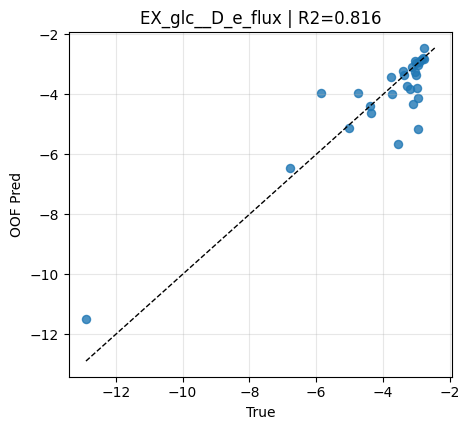

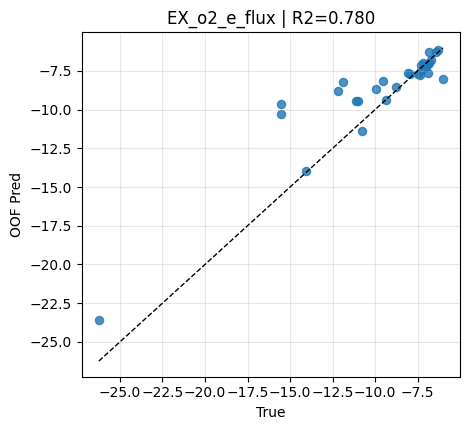

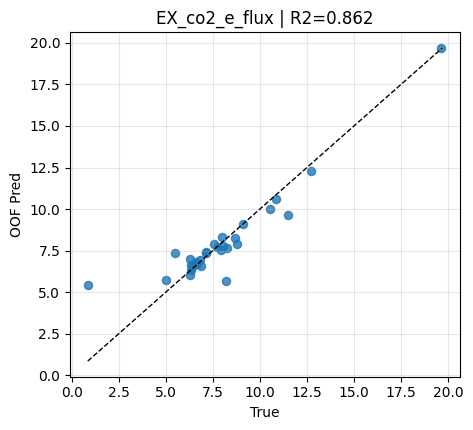

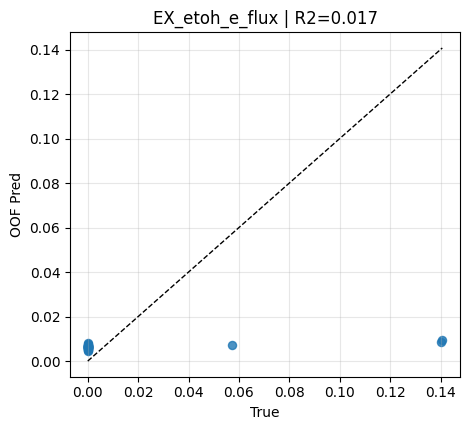

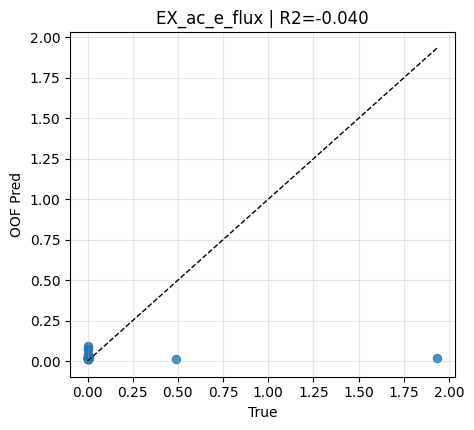

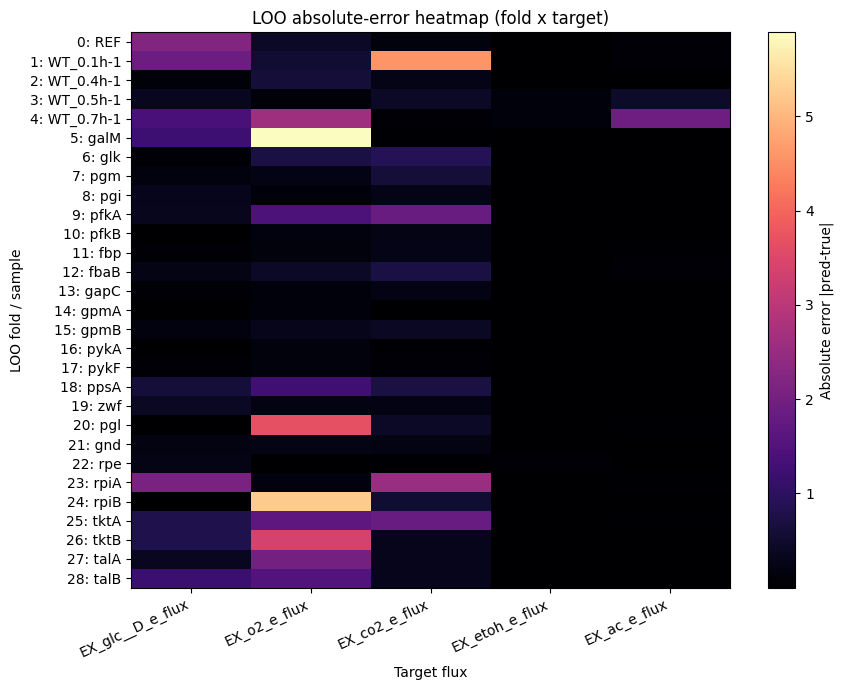

Top 5 worst folds by mean |error| across 5 targets:
  1. fold=5 exp=galM mean_abs_err=1.436682
  2. fold=1 exp=WT_0.1h-1 mean_abs_err=1.426117
  3. fold=4 exp=WT_0.7h-1 mean_abs_err=1.226322
  4. fold=24 exp=rpiB mean_abs_err=1.162133
  5. fold=23 exp=rpiA mean_abs_err=0.971156


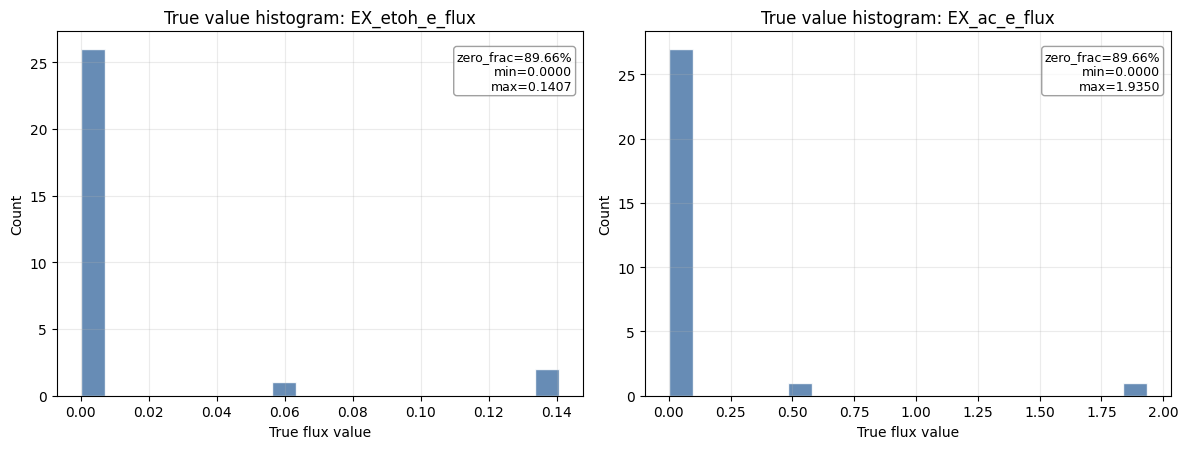

In [25]:
# Investigate the 5 fluxes predicted by the front MLP in a dedicated cell
# - pre_transformer_constraints: c0 channels before FluxTransformer
# - OOF metrics/scatter from nested CV run

inspect_fluxes = list(minn_target_token_names)

if len(inspect_fluxes) != 5:
    raise ValueError(f"Expected exactly 5 predicted fluxes, got {len(inspect_fluxes)}: {inspect_fluxes}")

# indices in vocabulary
token_to_idx = {tok: i for i, tok in enumerate(outputs)}
inspect_indices = [token_to_idx[f] for f in inspect_fluxes]

# Build c0 for all samples
X_all_t = torch.tensor(X_minn_np, dtype=torch.float32, device=device)
minn_model.eval()
with torch.no_grad():
    c0_all = minn_model.build_full_input_vector(X_all_t).detach().cpu().numpy()  # [N, vocab]

# summary
rows = []
for flux, idx in zip(inspect_fluxes, inspect_indices):
    cvals = c0_all[:, idx]
    col = inspect_fluxes.index(flux)

    row = {
        "flux": flux,
        "vocab_idx": idx,
        "pre_transformer_mean": float(np.mean(cvals)),
        "pre_transformer_std": float(np.std(cvals, ddof=1)) if len(cvals) > 1 else 0.0,
        "pre_transformer_min": float(np.min(cvals)),
        "pre_transformer_max": float(np.max(cvals)),
        "oof_r2": float(r2_score(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
        "oof_mae": float(mean_absolute_error(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
        "oof_rmse": float(root_mean_squared_error(oof_true[:, col], oof_pred[:, col])) if 'oof_true' in globals() else np.nan,
    }
    rows.append(row)

inspect_df = pd.DataFrame(rows)
print("5 front-MLP predicted fluxes: constraint stats + OOF metrics")
display(inspect_df)

# one scatter per flux
if 'oof_true' in globals() and 'oof_pred' in globals():
    for i, flux in enumerate(inspect_fluxes):
        y_t = oof_true[:, i]
        y_p = oof_pred[:, i]
        r2_val = r2_score(y_t, y_p)

        plt.figure(figsize=(4.8, 4.4))
        plt.scatter(y_t, y_p, alpha=0.8, s=34)
        lo = float(min(y_t.min(), y_p.min()))
        hi = float(max(y_t.max(), y_p.max()))
        plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
        plt.xlabel("True")
        plt.ylabel("OOF Pred")
        plt.title(f"{flux} | R2={r2_val:.3f}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # fold x target absolute-error heatmap
    abs_err = np.abs(oof_pred - oof_true)  # [n_folds, 5]
    fold_mean_err = abs_err.mean(axis=1)

    # Keep native LOO order by default. Optionally switch to worst-first order.
    sort_worst_first = False
    if sort_worst_first:
        row_order = np.argsort(-fold_mean_err)
    else:
        row_order = np.arange(abs_err.shape[0])

    abs_err_plot = abs_err[row_order]

    plt.figure(figsize=(9.0, 7.0))
    im = plt.imshow(abs_err_plot, aspect='auto', interpolation='nearest', cmap='magma')
    cbar = plt.colorbar(im)
    cbar.set_label('Absolute error |pred-true|')

    plt.xticks(np.arange(len(inspect_fluxes)), inspect_fluxes, rotation=25, ha='right')

    # y-axis labels: fold index (+ experiment when available)
    if 'minn_experiments' in globals() and len(minn_experiments) == abs_err.shape[0]:
        y_labels = [f"{int(i)}: {minn_experiments[i]}" for i in row_order]
    else:
        y_labels = [str(int(i)) for i in row_order]
    plt.yticks(np.arange(abs_err_plot.shape[0]), y_labels)

    plt.xlabel('Target flux')
    plt.ylabel('LOO fold / sample')
    plt.title('LOO absolute-error heatmap (fold x target)')
    plt.tight_layout()
    plt.show()

    # Print worst folds by mean absolute error across targets
    k = min(5, abs_err.shape[0])
    worst = np.argsort(-fold_mean_err)[:k]
    print(f"Top {k} worst folds by mean |error| across 5 targets:")
    for rank, i in enumerate(worst, start=1):
        exp_name = minn_experiments[i] if 'minn_experiments' in globals() and i < len(minn_experiments) else f"idx_{i}"
        print(f"  {rank}. fold={int(i)} exp={exp_name} mean_abs_err={float(fold_mean_err[i]):.6f}")

    # Histograms for ethanol and acetate TRUE values (from OOF true targets)
    etoh_idx = next((ii for ii, ff in enumerate(inspect_fluxes) if "etoh" in ff.lower()), None)
    ac_idx = next((ii for ii, ff in enumerate(inspect_fluxes) if "ac_e" in ff.lower() or "_ac_" in ff.lower()), None)

    hist_specs = []
    if etoh_idx is not None:
        hist_specs.append((etoh_idx, inspect_fluxes[etoh_idx]))
    if ac_idx is not None:
        hist_specs.append((ac_idx, inspect_fluxes[ac_idx]))

    if len(hist_specs) > 0:
        fig, axes = plt.subplots(1, len(hist_specs), figsize=(6.0 * len(hist_specs), 4.6), squeeze=False)
        axes = axes.ravel()

        for ax, (col_idx, flux_name) in zip(axes, hist_specs):
            vals = oof_true[:, col_idx].astype(float)
            ax.hist(vals, bins=20, alpha=0.85, color="#4c78a8", edgecolor="white")
            ax.set_title(f"True value histogram: {flux_name}")
            ax.set_xlabel("True flux value")
            ax.set_ylabel("Count")
            ax.grid(alpha=0.25)

            zero_frac = float(np.mean(np.isclose(vals, 0.0)))
            ax.text(
                0.98,
                0.95,
                f"zero_frac={zero_frac:.2%}\nmin={vals.min():.4f}\nmax={vals.max():.4f}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="gray"),
            )

        plt.tight_layout()
        plt.show()
    else:
        print("Could not find etoh/ac target columns in inspect_fluxes.")
else:
    print("Run the nested CV training cell first to generate OOF outputs.")




### TabPFN ML-to-flux benchmark

Goncalves-style Table 2 benchmark: transcriptomics + proteomics + fixed glucose/O2 uptake inputs, 45 flux targets, leave-one-out CV, fold-local scaling, and R2/MAE/RMSE/NE reported as mean +/- std across samples.

In [26]:
# TabPFN benchmark in the same style as Goncalves et al. / Tazza et al. Table 2
#
# Settings intentionally mirror the ML2Flux benchmark row used in Table 2:
# - Inputs: transcriptomics + proteomics + measured glucose/O2 uptake fluxes
# - Targets: all fluxomics outputs except the fixed uptake fluxes (45 targets)
# - No omics standard-deviation features
# - Outer CV: leave-one-out over 29 Ishii samples
# - Scaling: StandardScaler fit only on each training fold for X and y
# - Metrics: per-sample R2, MAE, RMSE, NE, then mean +/- std across folds
#
# TabPFNRegressor is single-output, so each flux target is fitted independently
# inside a fold, equivalent in spirit to sklearn MultiOutputRegressor(SVR())
# used for SVM in the Goncalves repository.

import inspect
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from tabpfn import TabPFNRegressor

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

hf_token = os.getenv("HFTOKEN") or os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_HUB_TOKEN")
if hf_token:
    os.environ.setdefault("HF_TOKEN", hf_token)
    os.environ.setdefault("HUGGINGFACE_HUB_TOKEN", hf_token)

TABPFN_DATA_DIR = Path("./MINN_data")
TABPFN_FLUXOMICS_FILE = "fluxomics.csv"  # original Goncalves/Ishii signed flux table, not the FBA-fit split table
TABPFN_PRIOR_FLUXES = ["R_EX_glc_e_", "R_EX_o2_e_"]
TABPFN_RANDOM_STATE = 12345
TABPFN_CV_RANDOM_STATE = 12345
TABPFN_DEVICE = "auto"
TABPFN_N_ESTIMATORS = 8  # TabPFN default; no HPO, analogous to default classical ML models in Goncalves
TABPFN_SHOW_TARGET_PROGRESS = False


def _load_goncalves_style_ishii_data(data_dir: Path):
    transcript_path = data_dir / "transcriptomics.csv"
    proteomics_path = data_dir / "proteomics.csv"
    fluxomics_path = data_dir / TABPFN_FLUXOMICS_FILE

    missing = [p for p in [transcript_path, proteomics_path, fluxomics_path] if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing benchmark input files: " + ", ".join(str(p) for p in missing))

    tr = pd.read_csv(transcript_path).set_index("experiment")
    pr = pd.read_csv(proteomics_path).set_index("experiment")
    fl = pd.read_csv(fluxomics_path).set_index("experiment")

    # Preserve the fluxomics/Ishii sample order used for target rows.
    sample_index = fl.index.intersection(tr.index).intersection(pr.index)
    if len(sample_index) == 0:
        raise RuntimeError("No overlapping experiment IDs between transcriptomics, proteomics, and fluxomics.")
    sample_index = [idx for idx in fl.index if idx in set(sample_index)]

    x_df = pd.concat(
        [
            tr.loc[sample_index].add_prefix("transcriptomics_"),
            pr.loc[sample_index].add_prefix("proteomics_"),
        ],
        axis=1,
    )
    y_df = fl.loc[sample_index].copy()

    missing_prior = [c for c in TABPFN_PRIOR_FLUXES if c not in y_df.columns]
    if missing_prior:
        raise ValueError("Missing fixed uptake flux columns in fluxomics.csv: " + ", ".join(missing_prior))

    # ML2Flux/Goncalves fixed-uptake setup: append measured uptake fluxes to X and remove them from y.
    x_df = pd.concat([x_df, y_df[TABPFN_PRIOR_FLUXES]], axis=1)
    y_df = y_df.drop(columns=TABPFN_PRIOR_FLUXES)

    return x_df, y_df


def _make_tabpfn_regressor(seed: int):
    params = inspect.signature(TabPFNRegressor).parameters
    kwargs = {}
    if "device" in params:
        kwargs["device"] = TABPFN_DEVICE
    if "n_estimators" in params:
        kwargs["n_estimators"] = TABPFN_N_ESTIMATORS
    if "show_progress" in params:
        kwargs["show_progress"] = False
    if "random_state" in params:
        kwargs["random_state"] = seed
    elif "seed" in params:
        kwargs["seed"] = seed
    return TabPFNRegressor(**kwargs)


def _per_sample_r2_corr_squared(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    out = np.zeros(y_true.shape[0], dtype=np.float64)
    for i in range(y_true.shape[0]):
        yt = y_true[i]
        yp = y_pred[i]
        if np.std(yt) == 0.0 or np.std(yp) == 0.0:
            out[i] = 0.0
            continue
        r = np.corrcoef(yt, yp)[0, 1]
        out[i] = 0.0 if np.isnan(r) else float(r * r)
    return out


def _per_sample_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    diff = y_true - y_pred
    denom = np.linalg.norm(y_true, axis=1)
    return {
        "R2": _per_sample_r2_corr_squared(y_true, y_pred),
        "MAE": np.mean(np.abs(diff), axis=1),
        "RMSE": np.sqrt(np.mean(diff ** 2, axis=1)),
        "NE": np.nan_to_num(np.linalg.norm(diff, axis=1) / denom, posinf=0.0, neginf=0.0, nan=0.0),
    }


def _format_mean_std(avg, std):
    return f"{avg:.3f} +/- {std:.3f}"


X_tabpfn_df, y_tabpfn_df = _load_goncalves_style_ishii_data(TABPFN_DATA_DIR)
X_tabpfn = X_tabpfn_df.to_numpy(dtype=np.float32)
y_tabpfn = y_tabpfn_df.to_numpy(dtype=np.float32)

n_samples, n_features = X_tabpfn.shape
n_targets = y_tabpfn.shape[1]

if n_samples < 2:
    raise ValueError("Need at least two samples for leave-one-out CV.")

print("=== TabPFN Goncalves-style ML-to-flux benchmark ===")
print(f"Samples: {n_samples}")
print(f"Features: {n_features} (transcriptomics + proteomics + fixed uptake fluxes)")
print(f"Targets: {n_targets} fluxes (fixed uptake fluxes removed)")
print(f"Fixed uptake features: {TABPFN_PRIOR_FLUXES}")
print(f"Fluxomics file: {TABPFN_DATA_DIR / TABPFN_FLUXOMICS_FILE}")
print(f"TabPFN n_estimators: {TABPFN_N_ESTIMATORS}, device: {TABPFN_DEVICE}")

kfold = KFold(n_splits=n_samples, shuffle=True, random_state=TABPFN_CV_RANDOM_STATE)

tabpfn_predictions_matrix = []
tabpfn_fold_rows = []
tabpfn_oof_pred = np.zeros_like(y_tabpfn, dtype=np.float32)
tabpfn_oof_true = y_tabpfn.copy()

start_time = time.time()

for fold_no, (train_idx, test_idx) in enumerate(kfold.split(X_tabpfn, y_tabpfn), start=1):
    sc_X = StandardScaler()
    sc_y = StandardScaler()

    X_train = sc_X.fit_transform(X_tabpfn[train_idx]).astype(np.float32)
    y_train = sc_y.fit_transform(y_tabpfn[train_idx]).astype(np.float32)
    X_test = sc_X.transform(X_tabpfn[test_idx]).astype(np.float32)
    y_test = sc_y.transform(y_tabpfn[test_idx]).astype(np.float32)

    y_pred_scaled = np.zeros_like(y_test, dtype=np.float32)

    print("------------------------------------------------------------------------")
    print(f"[TabPFN] Training for LOO fold {fold_no}/{n_samples} | test={X_tabpfn_df.index[test_idx[0]]}")

    for target_idx, target_name in enumerate(y_tabpfn_df.columns):
        y_train_target = y_train[:, target_idx]

        # TabPFN can be brittle with perfectly constant training targets; this is the exact constant predictor.
        if np.allclose(y_train_target, y_train_target[0]):
            y_pred_scaled[:, target_idx] = y_train_target[0]
            continue

        reg = _make_tabpfn_regressor(seed=TABPFN_RANDOM_STATE)
        reg.fit(X_train, y_train_target)
        pred = np.asarray(reg.predict(X_test), dtype=np.float32).reshape(-1)
        if pred.shape[0] != X_test.shape[0]:
            raise RuntimeError(
                f"Unexpected TabPFN prediction shape for target {target_name}: {pred.shape}, expected ({X_test.shape[0]},)"
            )
        y_pred_scaled[:, target_idx] = pred

        if TABPFN_SHOW_TARGET_PROGRESS and (target_idx + 1) % 10 == 0:
            print(f"  fitted {target_idx + 1}/{n_targets} targets")

    y_pred = sc_y.inverse_transform(y_pred_scaled).astype(np.float32)
    y_true = sc_y.inverse_transform(y_test).astype(np.float32)

    tabpfn_oof_pred[test_idx] = y_pred
    tabpfn_predictions_matrix.append((int(test_idx[0]), y_pred[0].copy()))

    fold_metrics = _per_sample_metrics(y_true, y_pred)
    row = {
        "fold": int(fold_no),
        "sample_index": int(test_idx[0]),
        "experiment": str(X_tabpfn_df.index[test_idx[0]]),
        "R2": float(fold_metrics["R2"][0]),
        "MAE": float(fold_metrics["MAE"][0]),
        "RMSE": float(fold_metrics["RMSE"][0]),
        "NE": float(fold_metrics["NE"][0]),
    }
    tabpfn_fold_rows.append(row)
    print(
        f"Score for fold {fold_no}: "
        f"R2={row['R2']:.4f}; MAE={row['MAE']:.6f}; "
        f"RMSE={row['RMSE']:.6f}; NE={row['NE']:.6f}"
    )

tabpfn_fold_metrics_df = pd.DataFrame(tabpfn_fold_rows)

metric_order = ["R2", "MAE", "RMSE", "NE"]
tabpfn_summary_numeric_df = pd.DataFrame(
    {
        "avg": [float(tabpfn_fold_metrics_df[m].mean()) for m in metric_order],
        "std": [float(tabpfn_fold_metrics_df[m].std(ddof=0)) for m in metric_order],
    },
    index=metric_order,
)

tabpfn_table2_row_df = pd.DataFrame(
    [
        {
            "Model": "TabPFN",
            **{
                m: _format_mean_std(
                    float(tabpfn_summary_numeric_df.loc[m, "avg"]),
                    float(tabpfn_summary_numeric_df.loc[m, "std"]),
                )
                for m in metric_order
            },
        }
    ]
)

tabpfn_predictions_matrix.sort(key=lambda x: x[0])
tabpfn_predictions_df = pd.DataFrame(
    [x[1] for x in tabpfn_predictions_matrix],
    index=X_tabpfn_df.index,
    columns=y_tabpfn_df.columns,
).T

tabpfn_oof_true_df = pd.DataFrame(tabpfn_oof_true, index=X_tabpfn_df.index, columns=y_tabpfn_df.columns)
tabpfn_oof_pred_df = pd.DataFrame(tabpfn_oof_pred, index=X_tabpfn_df.index, columns=y_tabpfn_df.columns)

elapsed_min = (time.time() - start_time) / 60.0

print("------------------------------------------------------------------------")
print(f"TabPFN benchmark finished in {elapsed_min:.1f} min")
print("=== TabPFN Table 2-style row ===")
display(tabpfn_table2_row_df)
print("=== Numeric summary ===")
display(tabpfn_summary_numeric_df)
print("=== Fold metrics ===")
display(tabpfn_fold_metrics_df)

# Optional convenience comparison: if the omics2flux cached table is present, append the matching Goncalves rows.
goncalves_overall_path = Path("omics2flux/results/overall_results.csv")
if goncalves_overall_path.exists():
    goncalves_overall_df = pd.read_csv(goncalves_overall_path)
    ref_specs = [
        ("pFBA*", (goncalves_overall_df["Model"] == "pFBA")),
        (
            "NN*",
            (goncalves_overall_df["Model"] == "NN")
            & (goncalves_overall_df["Omics"] == "T+P")
            & (goncalves_overall_df["Uptakes"].astype(str) == "1")
            & (goncalves_overall_df["Deviations"].astype(str) == "0"),
        ),
        (
            "RF*",
            (goncalves_overall_df["Model"] == "RF")
            & (goncalves_overall_df["Omics"] == "T+P")
            & (goncalves_overall_df["Uptakes"].astype(str) == "1")
            & (goncalves_overall_df["Deviations"].astype(str) == "0"),
        ),
    ]

    reference_rows = []
    for label, mask in ref_specs:
        rows = goncalves_overall_df.loc[mask]
        if rows.empty:
            continue
        r = rows.iloc[0]
        reference_rows.append(
            {
                "Model": label,
                "R2": _format_mean_std(float(r["R2"]), float(r["R2_SD"])),
                "MAE": _format_mean_std(float(r["MAE"]), float(r["MAE_SD"])),
                "RMSE": _format_mean_std(float(r["RMSE"]), float(r["RMSE_SD"])),
                "NE": _format_mean_std(float(r["NE"]), float(r["NE_SD"])),
            }
        )

    if reference_rows:
        tabpfn_table2_comparison_df = pd.concat(
            [pd.DataFrame(reference_rows), tabpfn_table2_row_df],
            ignore_index=True,
        )
        print("=== Table 2-style comparison with cached Goncalves rows ===")
        display(tabpfn_table2_comparison_df)


=== TabPFN Goncalves-style ML-to-flux benchmark ===
Samples: 29
Features: 141 (transcriptomics + proteomics + fixed uptake fluxes)
Targets: 45 fluxes (fixed uptake fluxes removed)
Fixed uptake features: ['R_EX_glc_e_', 'R_EX_o2_e_']
Fluxomics file: MINN_data\fluxomics.csv
TabPFN n_estimators: 8, device: auto
------------------------------------------------------------------------
[TabPFN] Training for LOO fold 1/29 | test=tktA
Score for fold 1: R2=0.9729; MAE=0.301595; RMSE=0.580070; NE=0.148093
------------------------------------------------------------------------
[TabPFN] Training for LOO fold 2/29 | test=gpmB
Score for fold 2: R2=0.9912; MAE=0.103702; RMSE=0.230077; NE=0.085272
------------------------------------------------------------------------
[TabPFN] Training for LOO fold 3/29 | test=zwf
Score for fold 3: R2=0.9808; MAE=0.245592; RMSE=0.339671; NE=0.129790
------------------------------------------------------------------------
[TabPFN] Training for LOO fold 4/29 | test=WT

,Model,R2,MAE,RMSE,NE
0,TabPFN,0.969 +/- 0.034,0.369 +/- 0.594,0.562 +/- 0.774,0.197 +/- 0.172


=== Numeric summary ===


,avg,std
R2,0.969187,0.034149
MAE,0.368767,0.594040
RMSE,0.561861,0.774108
NE,0.196814,0.171549


=== Fold metrics ===


,fold,sample_index,experiment,R2,MAE,RMSE,NE
0,1,25,tktA,0.972930,0.301595,0.580070,0.148093
1,2,15,gpmB,0.991164,0.103702,0.230077,0.085272
2,3,19,zwf,0.980823,0.245592,0.339671,0.129790
3,4,3,WT_0.5h-1,0.962955,0.930261,1.309730,0.278696
4,5,12,fbaB,0.967891,0.113820,0.352343,0.183031
5,6,0,REF,0.989457,0.077057,0.208225,0.096288
6,7,23,rpiA,0.983964,0.183911,0.298646,0.123428
7,8,8,pgi,0.834433,0.490874,0.765428,0.460426
8,9,20,pgl,0.990446,0.130694,0.232109,0.088275
9,10,7,pgm,0.965641,0.115923,0.419642,0.173666


=== Table 2-style comparison with cached Goncalves rows ===


,Model,R2,MAE,RMSE,NE
0,pFBA*,0.823 +/- 0.156,0.692 +/- 0.733,1.058 +/- 1.029,0.381 +/- 0.185
1,TabPFN,0.969 +/- 0.034,0.369 +/- 0.594,0.562 +/- 0.774,0.197 +/- 0.172
